## **Environment Setup (Local or Google Colab)**

The code block below automatically detects your execution runtime environment (Local vs. Google Colab), clones the repository, and installs all necessary dependencies.

> **Google Colab Note:** Once setup completes, navigate to **Runtime → Restart session** in the top menu before proceeding to the next steps to ensure all newly installed packages are correctly loaded.

In [1]:
import os
import subprocess
import sys

# Environment Detection: Check sys.modules for Colab runtime
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    print("Detected Google Colab environment. Initializing setup...")

    # Define paths
    branch = "dev-ch3"
    repo_url = (
        "https://github.com/paymantohidifar/deep-learning-for-biology-book.git"
    )
    target_dir = "/content/dlfb"

    # Clean stale builds and clone main branch
    subprocess.run(f"rm -rf {target_dir}", shell=True, check=True)
    subprocess.run(
        f"git clone {repo_url} --branch {branch} {target_dir}",
        shell=True,
        check=True,
    )
    print("Cloned the repo.")

    # Change working directory
    os.chdir(target_dir)

    # Bootstrap uv and install dependencies into system environment
    install_cmd = (
        'curl -LsSf https://astral.sh/uv/install.sh | sh && '
        'export PATH="$HOME/.local/bin:${PATH}" && '
        'uv pip install -e .[gpu] --system --break-system-packages --color never'
    )
    print("Installing dependencies...")
    subprocess.run(install_cmd, shell=True, check=True)
    print("Colab setup complete.")

    # Download chapter data
    print("Downloading chapter data ...")
    subprocess.run(
        "dlfb-provision --chapter dna",
        shell=True,
        check=True,
    )
    print("Downloading data complete.")
else:
    # Local Development: Enable IPython Auto-Reload safely
    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")
        print("Enabled IPython autoreload.")

    # Download chapter data
    print("Downloading chapter data ...")
    subprocess.run(
        "dlfb-provision --chapter dna --destination ../data",
        shell=True,
        check=True,
    )
    print("Downloading data complete.")

Enabled IPython autoreload.


Files Downloaded:  95%|█████████▌| 252/264 [00:01<00:00, 249.00file/s]

Files Downloaded: 100%|██████████| 264/264 [00:01<00:00, 182.17file/s]


## **Load the `dlfb` package**  

Load the `dlfb` package.

**Note:** Loading can sometimes be finicky. If you encounter issues, simply **restart the runtime**. All previously downloaded data and installed packages will persist, so you can re-run the load step without repeating everything.

In [2]:
# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=False


## **Verify Packages**  

In [3]:
from importlib.metadata import version

required_pkgs = [
    "pandas",
    "numpy",
    "tensorflow",
]
for pkg in required_pkgs:
    print(f"{pkg}: {version(pkg)}")

pandas: 2.2.2
numpy: 2.1.2
tensorflow: 2.19.0


---

# **Chapter 3: Learning the Logic of DNA**

In this chapter, we will build and train deep learning models from scratch to predict whether DNA sequences are bound by transcription factors (TFs). Unlike the previous chapter, we will define our own architectures, specifically convolutional neural networks (CNNs) and transformers, to decode genomic regulatory logic.

The project follows a three-stage roadmap:
* **Simple Prototype:** Training a basic CNN to predict the binding of a single transcription factor, CTCF.
* **Increased Complexity:** Scaling up to 10 different TFs while introducing regularization, normalization, and interpretability techniques like in silico mutagenesis and input gradients.
* **Advanced Techniques:** Incorporating transformer layers to capture long-range dependencies and analyzing how these architectural choices impact learning.

This staged approach is designed to build confidence while ensuring the models remain debuggable and interpretable. 

---

## **Table of Contents**

- [Biology Primer](#biology-primer)
- [Machine Learning Primer](#machine-learning-primer)
  - [Convolutional Neural Networks](#convolutional-neural-networks)
    - [Core Mechanisms and Components](#core-mechanisms-and-components)
  - [Convolutions for DNA Sequences](#convolutions-for-dna-sequences)
    - [Importance for DNA Analysis](#importance-for-dna-analysis)
    - [Strengths and Limitations](#strengths-and-limitations)
  - [Transformers](#transformers)
  - [Attention](#attention)
  - [Query, Key and Value Intuition](#query-key-and-value-intuition)
  - [Multiheaded Attention](#multiheaded-attention)
  - [Representing Positional Information](#representing-positional-information)
  - [Model Interpretation](#model-interpretation)
  - [In Silico Saturation Mutagenesis](#in-silico-saturation-mutagenesis)
  - [Input Gradients](#input-gradients)
- [Building a Simple Prototype](#building-a-simple-prototype)
  - [Building a Dataset](#building-a-dataset)
    - [Loading the Labeled Sequences](#loading-the-labeled-sequences)
    - [Convert the Data to a TensorFlow Dataset](#convert-the-data-to-a-tensorflow-dataset)
  - [Defining a Simple Convolutional Model](#defining-a-simple-convolutional-model)
    - [Examining Model Tensor Shapes](#examining-model-tensor-shapes)
    - [Making Predictions with the Model](#making-predictions-with-the-model)
    - [Defining a Loss Function](#defining-a-loss-function)
    - [Defining the TrainState](#defining-the-trainstate)
    - [Defining a Single Training Step](#defining-a-single-training-step)
    - [Training the Simple Model](#training-the-simple-model)
    - [Sanity Checking the Model](#sanity-checking-the-model)
- [Increasing Complexity](#increasing-complexity)
  - [Conducting In Silico Mutagenesis](#conducting-in-silico-mutagenesis)
    - [Implementing In Silico Saturation Mutagenesis](#implementing-in-silico-saturation-mutagenesis)
    - [Verifying Motif Presence](#verifying-motif-presence)
    - [Implementing Input Gradients](#implementing-input-gradients)
  - [Modelling Multiple Transcription Factors](#modelling-multiple-transcription-factors)
    - [Preparing a Multi-TF Dataset](#preparing-a-multi-tf-dataset)
    - [Defining a More Complex Model](#defining-a-more-complex-model)
    - [Defining Various Model Architectures](#defining-various-model-architectures)
    - [Sweeping Over the Different Models](#sweeping-over-the-different-models)
    - [Evaluating on the Test Split](#evaluating-on-the-test-split)
    - [Why Are Some TFs Harder to Model Than Others?](#why-are-some-tfs-harder-to-model-than-others)
- [Advanced Techniques](#advanced-techniques)
  - [Adding Self-attention and Transformer Blocks](#adding-self-attention-and-transformer-blocks)
  - [Defining Various Model Architectures](#defining-various-model-architectures-1)
  - [Sweeping Over the Different Models](#sweeping-over-the-different-models-1)
  - [Evaluating on the Test Split](#evaluating-on-the-test-split-1)
  - [Extensions and Improvements](#extensions-and-improvements)
- [Summary](#summary)

---

## **Biology Primer**

DNA consists of four chemical bases (A, C, G, T) that carry the genetic instructions for building a human body across a 3.2-billion-base-pair genome. While only 2% of the genome codes for proteins, the remaining 98% is noncoding DNA that performs critical regulatory roles, such as serving as docking sites for regulatory proteins. These proteins, known as **transcription factors (TFs)**, act as conductors that control gene activity by binding to short, specific DNA sequences called **motifs**. 

Not every matching motif is actually bound in a living cell. In fact, the genome contains far more motif matches than actual binding events. That’s because
binding depends on many additional factors:

**Chromatin accessibility**: DNA that’s tightly packed into chromatin is harder for proteins to access. TFs are more likely to bind in regions of open chromatin.

**DNA methylation**: Certain TFs, like CTCF, are sensitive to methylation (a certain chemical modification of DNA bases) at their binding sites, which can block binding even if the motif is present.

**Cellular signals**: Signals inside the cell, such as hormones or stress responses, can activate or deactivate a TF’s ability to bind.
    
**Other proteins**: Helper or blocking proteins in the local environment can facilitate or inhibit binding.

**Cooperative binding**: Many TFs work in complexes or recruit others to stabilize binding and control gene activity.

And perhaps most importantly, real cells are dynamic. Molecules move, concentrations change, and TF binding events happen on short timescales. Most genomic datasets, by contrast, are static snapshots, freeze-frames of a constantly changing scene. That’s worth keeping in mind when interpreting binding data in this chapter.

Researchers use a laboratory technique called **ChIP-seq** to capture snapshots of these binding events, which are then simplified into binary labels (bound or not bound) for deep learning models to learn. This biological foundation is what our models will attempt to decode.

---

## **Machine Learning Primer**

This section briefly cover convolutional and transformer-based architectures, how they can be applied to biological sequence data like DNA, and what kinds of insights they can provide.

### **Convolutional Neural Networks**

Convolutional Neural Networks (CNNs) were originally developed for image recognition tasks. In images, low-level features like edges and textures appear in small local patches, while higher-level
concepts like shapes or objects are formed by combining these local features. CNNs mirror this structure by using small, learnable filters that slide across the input, extracting local patterns at each position. As we stack more layers, the model combines local features into more abstract and global representations.

Their core strength lies in their ability to automatically learn useful patterns from raw, grid-like input data, whether that’s pixels in an image or bases in a DNA sequence, without the need for hand-engineered features.

#### **Core Mechanisms and Components**

* **Filters (Kernels):** These are small learnable weight matrices that "slide" across the input sequence to perform dot product operations. They act as pattern detectors, producing feature maps that highlight where specific motifs occur.
* **Pooling Layers:** These layers downsample feature maps to reduce computational load and dimensionality. Max pooling, for instance, retains only the strongest signal in a region, helping the model focus on the most salient biological features.
* **Normalization:** Layers like batch normalization rescale activations to reduce internal covariate shift, making training more stable and accelerating convergence.
* **Fully Connected Layers:** Located at the end of the network, these layers use the extracted features to make final predictions, such as determining if a sequence is bound by a transcription factor.

### **Convolutions for DNA Sequences**

CNNs have become a standard architecture for biological sequence data because they automatically learn hierarchical patterns directly from raw inputs, such as the bases in a DNA sequence.

#### **Importance for DNA Analysis**

* **Translation Equivariance:** This is a critical property for genomics; it ensures that a binding motif is recognized regardless of its specific position (e.g., index 10 or 90) within the DNA sequence.
* **1D Convolutions:** While CNNs were popularized for 2D images, genomics uses 1D filters applied to one-hot encoded DNA matrices (where A, C, G, and T are represented as binary vectors). 
* **Hierarchical Learning:** Shallow layers typically detect simple low-level features like GC-rich regions, while deeper layers identify high-order combinations and complex motifs.

#### **Strengths and Limitations**

CNNs offer an excellent balance of power, speed, and interpretability, as researchers can visualize exactly which motifs a specific filter has learned to detect. However, they are limited by their fixed window size, which makes it difficult for them to model long-range dependencies between elements located far apart on the genome. This is where we turn to a different class of models such as transformers.

### **Transformers**

Transformers are powerful for DNA analysis because their self-attention mechanism can capture long-range dependencies between motifs that are far apart in a sequence. Self-Attention allows each position in a sequence to dynamically focus on every other position to determine relevance. It enriches each token's embedding with global contextual information.

While transformers excel at modeling complex relationships that CNNs struggle with, their computational cost grows quadratically with sequence length, which can be a bottleneck for very long genomic inputs.

### **Attention**

The Attention mechanism is the core of the transformer architecture, allowing the model to enrich each token's embedding with information from every other token in a sequence, making them "context-aware".

#### **The Mechanism: Queries, Keys, and Values**

The model transforms input embeddings into three distinct perspectives through learned linear transformations:
* **Queries (Q):** Define what a token is "looking for" (e.g., a specific upstream motif).
* **Keys (K):** Advertise what information a token "contains".
* **Values (V):** Provide the actual content passed along if a Query matches a Key.

By comparing Queries to all Keys using a dot product, the model generates attention weights (via scaled softmax) that determine how much of each Value vector is summed into the token’s new representation.

#### **Biological Significance**

In genomics, this allows the model to integrate signals across arbitrary distances, such as determining if a regulatory motif is influenced by an element thousands of bases away. This "smart lookup system" enables the model to learn complex, long-range dependencies that fixed-size convolutional windows might miss.

### **Query, Key and Value Intuition**

The Query, Key, and Value (Q, K, V) projections allow the model to treat a sequence as a "smart lookup system," where each token views the data from different perspectives:

* **Query (Q):** Acts as a "lens" for a token to express what information it is looking for (e.g., a specific motif).
* **Key (K):** Acts as an **advertisement** of what content a token contains.
* **Value (V):** The **actual content** that is passed along when a Query successfully matches a Key.

By separating these roles, the model doesn't treat all parts of a sequence as equally relevant; instead, each token pulls a weighted mixture of Values based on how well its Query matched the others' Keys. These projections are not fixed but are learned from data during training.

### **Multiheaded Attention**

Multiheaded Attention (MHA) enhances the transformer's ability to process complex sequences by running several attention operations, or "heads," in parallel. 

* **Diverse Perspectives:** Each head can focus on different scales or patterns simultaneously, for example, one head might detect a local binding motif while another identifies long-range interactions thousands of bases away.
* **Integration:** The outputs from all heads are concatenated and linearly transformed to produce a final representation that is richer and more expressive than a single attention operation could achieve.
* **Biological Utility:** This parallel structure is specifically useful for biological sequences where various signals and dependencies exist at different scales.

### **Representing Positional Information**

Self-attention is inherently **position invariant**, meaning it cannot distinguish the order or position of bases on its own. To address this, Transformer models typically use positional encodings, such as sinusoidal functions of the token index, to inject information about sequence order.

In the specific model built in this chapter, the authors omit explicit positional encodings as a simplification. They suggest that for short 200 bp sequences, the convolutional layers preceding the attention block can sufficiently capture the relative arrangement of motifs.

### **Model Interpretation**

Model interpretation techniques help peek inside the "black box" of deep learning to understand how models make specific biological predictions. The chapter focuses on two primary methods for generating "saliency maps" that highlight influential DNA regions:

* **In Silico Saturation Mutagenesis (ISM)**: This method involves systematically mutating every base in a sequence to all other possible bases and recording the change in the model's output. While computationally expensive due to the high number of forward passes required, it is highly intuitive and provides direct evidence of which motifs are critical for binding.
* **Input Gradients**: This is a much faster, mathematical alternative that computes the derivative of the model's prediction with respect to the input. It measures the model's sensitivity to tiny perturbations at each position. Unlike ISM, gradients represent "directional sensitivity" rather than discrete substitutions, which can sometimes make them noisier or harder to interpret.
* **Attention Mechanisms**: For models using transformer layers, researchers can inspect attention weights to visualize which parts of a sequence the model is focusing on to integrate global context.

### **In Silico Saturation Mutagenesis**

In Silico Saturation Mutagenesis (ISM) is an interpretation technique used to identify which parts of a biological sequence are most important for a model's prediction.

The process involves systematically changing every base in a sequence to the other three possible bases and recording how each mutation affects the model's output. It produces a **saliency map** (often visualized as a heatmap) that highlights critical regions, such as binding motifs. If mutating a specific base significantly drops the predicted binding probability, that base is deemed essential for the model's decision.

**Pros and Cons**: ISM is highly intuitive and provides direct evidence of a motif's importance. However, it is computationally expensive because it requires a separate model forward pass for every possible mutation at every position.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="./images/figure_3_4.png" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 3.4</strong> Example of an in silico saturation mutagenesis plot showing predicted probabilities of transcription factor binding across a 200-base DNA sequence. The x-axis represents the DNA sequence positions, while the y-axis shows the three possible mutations at each position (including the mutation to the original base, which has no effect and is set to zero). In this example, most mutation effects are negative (darker color), indicating that changing bases generally reduces the predicted binding probability. This approach is computationally expensive due to the large number of forward passes required to generate this output matrix (here, 3 mutations × 200 positions = 600 model predictions).
    </figcaption>
</figure>

### **Input Gradients**

Input gradients serve as a fast, mathematical alternative to in silico mutagenesis for identifying influential regions in a DNA sequence. 

This technique computes the derivative of the model's output with respect to each input base, measuring how sensitive a prediction is to tiny, infinitesimal perturbations at every position. Unlike mutagenesis, gradients do not simulate actual base changes. Instead, they reflect "directional sensitivity," meaning even a base already present in the sequence can show a high gradient if the model relies heavily on it for its decision. A large gradient suggests that the base at that position has a significant influence on the prediction (e.g., a binding event), while low gradients indicate regions the model considers less important.

**Pros and Cons**: Gradients are highly computationally efficient, requiring only a single backward pass to generate an entire importance map. However, the resulting maps can be noisier and harder to interpret than those from mutagenesis due to model nonlinearities or saturation effects.

---

## **Building a Simple Prototype**

The prototype's goal is a binary classification task: predicting whether a 200-base DNA sequence binds to the transcription factor **CTCF**. CTCF is an ideal starting point because its binding behavior is highly predictable, thanks to a well-characterized and conserved motif with strong sequence specificity. 

Biologically, CTCF plays a key role in organizing the genome's 3D architecture by folding DNA into loops and domains that regulate gene activity. This staged approach allows for building a solid foundation before iteratively scaling to predict binding for 10 different TFs using more complex architectures.

### **Building a Dataset**

#### **Loading the Labeled Sequences**

In [4]:
import pandas as pd

from dlfb.utils.context import assets

train_df = pd.read_csv(assets("dna/datasets/CTCF_train_sequences.csv"))
print(train_df)

                                                sequence  label  \
0      TACCACATGAGTTCTCTTTCAGTTTGCTATGGAAGACACAAAAACC...      1   
1      CATCAACACTCGTGCGACGCCCTCGCATTTTCATTAATGATGGCCT...      0   
2      GCACACAGCGCAGGAACCTGGCACTGGAGAAGCCACCCAGGCTGTG...      1   
3      GCCAGCCGAAGCAGAGAGCAGTGCACATGCGTGCAGCTACCAGCAT...      1   
4      GTCCCGTCCCTTTTCGTGCCTCTGCCCCCACAGCTGCTGCAGTCTG...      1   
...                                                  ...    ...   
61078  AATATGACCCTGCTGGCCTTAGGCCTACTCCTGTACCACAAGTGCC...      0   
61079  GATAAACCAAGGTCGTAAGTTCAGGCTCCGCCTCCCCGCAGGGCCT...      1   
61080  CCTCCCTCCCATCCCCCACACAGTTTAATGTCTAGAAGGTTGCCTG...      1   
61081  CAGGAATGCACCGGAAGTCCGCCTCCCGGGACCCGCCGCCGGTCCC...      0   
61082  AAAACAGAAACTGAAACTTCAAACACAGAGACAGAAAAAAAAAAAA...      0   

      transcription_factor subset  
0                     CTCF  train  
1                     CTCF  train  
2                     CTCF  train  
3                     CTCF  train  
4              

Let's look at the class distribution:

In [5]:
train_df["label"].value_counts()

label
1    30545
0    30538
Name: count, dtype: int64

The two classes appear fairly balanced (equally represented) in the training dataset, so we won’t have to do any rebalancing by downsampling the majority class here.

To use the DNA sequences numerically, we need to convert them into one-hot format. The function `dna_to_one_hot` performs this mapping:

```python
def dna_to_one_hot(dna_sequence: str) -> np.ndarray:
    """Convert DNA into a one-hot encoded format with channel ordering ACGT."""
    base_to_one_hot = {
      "A": (1, 0, 0, 0),
      "C": (0, 1, 0, 0),
      "G": (0, 0, 1, 0),
      "T": (0, 0, 0, 1),
      "N": (1, 1, 1, 1),  # N represents any unknown or ambiguous base.
    }
    one_hot_encoded = np.array([base_to_one_hot[base] for base in dna_sequence])
    return one_hot_encoded

  ```

In [6]:
from dlfb.dna.utils import dna_to_one_hot

# display(["import numpy as np", dna_to_one_hot])

In [7]:
# Example test
dna_to_one_hot("AAACGT")

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])

We can apply this converter to the entire training dataset to generate the numerical training data x_train as follows:

In [8]:
import numpy as np

x_train = np.array([dna_to_one_hot(seq) for seq in train_df["sequence"]])
y_train = train_df["label"].values[:, None]

Here, `y_train` contains the binary target labels: **0** means the sequence does not bind CTCF, and **1** means the sequence does bind CTCF.

In [9]:
print(y_train.shape)

(61083, 1)


We can wrap two lines of code above into the `load_dataset` function:

```python
def load_dataset(sequence_db) -> dict[str, np.ndarray]:
    """Load sequences and labels from a CSV into numpy arrays."""
    df = pd.read_csv(sequence_db)
    return {
        "labels": df["label"].to_numpy()[:, None],
        "sequences": np.array([dna_to_one_hot(seq) for seq in df["sequence"]]),
        }
```

#### **Convert the Data to a TensorFlow Dataset**

Next, we convert the training data into a TensorFlow dataset using the `convert_to_tfds` function. This format makes it easy to efficiently iterate over batches during model training, especially when shuffling and repeating the data for multiple epochs:

```python
def convert_to_tfds(
    dataset,
    batch_size: int | None = None,
    is_training: bool = False
    ) -> tf.data.Datset:
    """Convert DNA sequences and labels to a TensorFlow dataset."""
    ds = tf.data.Dataset.from_tensor_slices(dataset)
    if is_training:
        ds = ds.shuffle(buffer_size=len(dataset["sequences"]))
        ds = ds.repeat()
    batch_size = batch_size or len(dataset["labels"])
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE) # Prepare the upcoming batch on cpu ready to be fed to GPU/TPU
    return ds

```

We then create the training dataset `train_ds` with batching, shuffling, and repetition enabled:

In [10]:
from dlfb.dna.dataset import load_dataset, convert_to_tfds

# display([convert_to_tfds])

batch_size = 32

train_ds = convert_to_tfds(
    load_dataset(assets("dna/datasets/CTCF_train_sequences.csv")),
    batch_size=batch_size,
    is_training=True,
)

2026-09-04 20:13:08.982577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788577989.063310   20776 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788577989.086657   20776 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788577989.271668   20776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788577989.271692   20776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788577989.271693   20776 computation_placer.cc:177] computation placer alr

Let’s sanity-check by pulling one batch from the dataset and inspecting its shape and contents:

In [11]:
batch = next(train_ds.as_numpy_iterator())
print(f'Batch sequence shape: {batch["sequences"].shape}')
print(f'Batch sequence instances: {batch["sequences"][:3,:3,]}...')
print(f'Batch labels shape: {batch["labels"].shape}')
print(f'Batch labels instances: {batch["labels"][:3,]}...')

Batch sequence shape: (32, 200, 4)
Batch sequence instances: [[[1 0 0 0]
  [0 1 0 0]
  [0 0 0 1]]

 [[0 1 0 0]
  [1 0 0 0]
  [0 0 1 0]]

 [[0 0 0 1]
  [0 0 0 1]
  [0 1 0 0]]]...
Batch labels shape: (32, 1)
Batch labels instances: [[1]
 [0]
 [0]]...


This looks sensible. We see the data has shape (32, 200, 4), indicating a batch size of 32, sequence length of 200, and 4 channels per DNA base as expected. The labels have shape (32, 1) since each label is a simple binary 0 or 1.

For validation, since the dataset is smaller, we can structure it as one single big batch:

In [12]:
valid_ds = load_dataset(assets("dna/datasets/CTCF_valid_sequences.csv"))

In [13]:
print(len(valid_ds["labels"]))
print(valid_ds['sequences'][0].shape)

8726
(200, 4)


With our data now in the correct format, we are ready to build and train our first simple model.

### **Defining a Simple Convolutional Model**

Next, we define a simple CNN composed of two 1D convolutional layers, followed by flattening and fully connected (dense) layers:

```python
class ConvModel(nn.Module):
  """Basic CNN model for binary sequence classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully-connected layer.

  @nn.compact
  def __call__(self, x):
    # First convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

  def create_train_state(self, rng, dummy_input, tx) -> TrainState:
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init = jax.random.split(rng)
    variables = self.init(rng_init, dummy_input)
    state = TrainState.create(
      apply_fn=self.apply, params=variables["params"], tx=tx
    )
    return state

```

Here is the schematic of the model we defined above:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="./images/1d_cnn_dnaseq.png" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>1D CNN Architecture Sketch for DNA Sequence</strong>
    </figcaption>
</figure>

In [14]:
# display([ConvModel], hide=[ConvModel.create_train_state])

This model architecture is fairly “no frills” but should already be able to capture local patterns in DNA sequences. We can instantiate our model like this:

In [15]:
from dlfb.dna.model import ConvModel

model = ConvModel()

To initialize model parameters in JAX, we need to provide a dummy input tensor that matches the expected shape of the model’s input. Although we could use an actual batch from our dataset, it is common and simpler to use a tensor of ones with batch size 1 and the same shape as a single-encoded DNA sequence. Importantly, the batch size used for this dummy input does not affect the model initialization; JAX initializes parameters based on the shape of an individual input sample (excluding the batch dimension). This means the model can later be trained or used for inference with any batch size.

In [16]:
import jax
import jax.numpy as jnp

dummy_input = jnp.ones((1, *batch["sequences"][1,].shape))
print(dummy_input.shape)

rng_init = jax.random.PRNGKey(42)
variables = model.init(rng_init, dummy_input)
params = variables["params"]

INFO:2026-09-04 20:13:16,392:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-09-04 20:13:16.392 INFO jax._src.xla_bridge xla_bridge - backends: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-09-04 20:13:16,402:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-09-04 20:13:16.402 INFO jax._src.xla_bridge xla_bridge - backends: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


(1, 200, 4)


Understanding and keeping track of tensor shapes is a crucial part of machine learning. Always make it a habit to verify the shapes of your data as it flows through the model. So let's confirm the shape of the input tensor along the model layers by printing out the shape of `x` after every transformation:

In [17]:
import flax.linen as nn
import jax
from flax.training.train_state import TrainState


class DummyConvModel(nn.Module):
  """Basic CNN model for binary sequence classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully-connected layer.

  @nn.compact
  def __call__(self, x):
    # First convolutional layer.
    print("Input shape:", x.shape)
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    print("Conv_1 shape:", x.shape)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))
    print("MP_1 shape:", x.shape)

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    print("Conv_2 shape:", x.shape)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))
    print("MP_2 shape:", x.shape)

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))
    print("Flatten:", x.shape)

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)
    print("Dense_1:", x.shape)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)
    print("Dense_2:", x.shape)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

  def create_train_state(self, rng, dummy_input, tx) -> TrainState:
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init = jax.random.split(rng)
    variables = self.init(rng_init, dummy_input)
    state = TrainState.create(
      apply_fn=self.apply, params=variables["params"], tx=tx
    )
    return state

dummy_model = DummyConvModel()
_ = dummy_model.init(rng_init, dummy_input)

Input shape: (1, 200, 4)
Conv_1 shape: (1, 200, 64)
MP_1 shape: (1, 100, 64)
Conv_2 shape: (1, 100, 64)
MP_2 shape: (1, 50, 64)
Flatten: (1, 3200)
Dense_1: (1, 128)
Dense_2: (1, 64)


#### **Examining Model Tensor Shapes**

Here are some key operations in the model that change tensor shapes:

* **Convolutional layers (`nn.Conv`):** These layers can modify the channel dimension. For example, our input starts with four channels (DNA bases), but the first convolution increases this to 64 channels, effectively learning 64 different sequence features or motifs. Additionally, the convolution’s padding option affects the sequence length dimension:
    * `padding='SAME'` preserves the sequence length.
    * `padding='VALID'` reduces it depending on the kernel size. Try switching between these in `DummyConvModel`to see the impact on the sequence length.

* **Max pooling layers (`nn.max_pool`):** These reduce the sequence length by downsampling. In our model, each max pooling layer halves the length, from 200 to 100 and then to 50 bases. To reduce the spatial axis more aggressively (e.g., by a factor of 2 each time), adjust the `window_shape` and `strides` arguments accordingly (typically, these are set to the same value to avoid overlapping windows and simplify downsampling).

* **Flattening (reshape):** Before passing data to dense layers, the tensor is reshaped from (`batch_size, sequence_length, channels`) to (`batch_size, flattened_features`). This collapses the spatial and channel dimensions into one long vector per example, preparing it for fully connected layers.

Once the model parameters are initialized, you can inspect them to confirm the layer structure and shapes. Check the parameter keys (layer names) with:

In [18]:
params.keys()

dict_keys(['Conv_0', 'Conv_1', 'Dense_0', 'Dense_1', 'Dense_2'])

In [19]:
for layer_name in params:
    print(f'Layer {layer_name} param shape: {params[layer_name]["kernel"].shape}')

Layer Conv_0 param shape: (10, 4, 64)
Layer Conv_1 param shape: (10, 64, 64)
Layer Dense_0 param shape: (3200, 128)
Layer Dense_1 param shape: (128, 64)
Layer Dense_2 param shape: (64, 1)


Some notes on these shapes:
* For convolutional layers, the parameter shape is (`kernel_size, input_channels, output_channels`). For example, `Conv_0` has kernel size 10, input channels 4 (DNA bases), and outputs 64 feature maps.
* Dense layers have shapes (`input_features, output_units`). For instance, `Dense_0` maps 3200 flattened features ($50 \times 64$) to 128 units.

With the model initialized and the parameter shapes explored, let’s start setting up our training loop.

#### **Making Predictions with the Model**

We can actually already obtain predictions from the model using the randomly initialized parameters, though the predictions will be random. We make predictions by calling model.apply on a batch of sequences:

In [20]:
logits = model.apply({"params": params}, batch["sequences"])

# Apply sigmoid to convert logits to probabilities.
probs = nn.sigmoid(logits)

# Print just the first few predictions.
print(probs[0:5])

[[0.49544188]
 [0.48372465]
 [0.49722096]
 [0.47167385]
 [0.48428485]]


Since the model is not trained yet, we can see that the predicted probabilities are around 0.5, reflecting pure guesswork from our randomly-parameterized model.

#### **Defining a Loss Function**

Let's now define a binary cross-entropy loss function using the `optax` library. We need this to be able to train our model. Note that we're predicting whether a TF binds to a given DNA sequence, a classic binary classification task. Binary cross-entropy is the standard loss function for this setting: it measures how well the model’s predicted probabilities align with the true binary labels.

In [21]:
import optax


def calculate_loss(params, batch):
    """Make predictions on batch and compute binary cross entropy loss."""
    logits = model.apply({"params": params}, batch["sequences"])
    loss = optax.sigmoid_binary_cross_entropy(logits, batch["labels"]).mean()
    return loss

In [22]:
calculate_loss(params, batch)

Array(0.6961616, dtype=float32)

This gives a baseline loss value before training. As the model learns, this loss should decrease substantially.

#### **Defining the `TrainState`**

To start training the model, we first need to define the optimizer. We’ll use **Adam** with a learning rate of **1e-3**, which is a common default value that tends to work well across diverse problems:

In [23]:
learning_rate = 0.001

tx = optax.adam(learning_rate)

With this, we now have all the components to initialize the training state. For this, we’ll use Flax’s `TrainState` class, which is a container that bundles all the important objects for training (the model, parameters, and optimizer):

In [24]:
from flax.training.train_state import TrainState

state = TrainState.create(apply_fn=model.apply, params=params, tx=tx)

For convenience, let’s define a function to create the train state:

In [25]:
def create_train_state(model, rng, dummy_input, tx) -> TrainState:
    variables = model.init(rng, dummy_input)
    state = TrainState.create(
      apply_fn=model.apply, params=variables["params"], tx=tx
    )
    return state

#### **Defining a Single Training Step**

Finally, putting everything together, we can write a function to run one training iteration, which performs these steps:

1. **Forward pass:** Takes a batch of data, makes model predictions, and computes loss based on the current parameters
2. **Backwards pass:** Computes gradients of the loss with respect to the parameters
3. **Update:** Using the computed gradients, updates the parameters to minimize the model’s loss

These steps happen in the `train_step` function:

In [26]:
@jax.jit
def train_step(state, batch):
    """Run single training step to compute gradients and update model params."""
    grad_fn = jax.value_and_grad(calculate_loss, has_aux=False)
    loss, grads = grad_fn(state.params, batch)
    state = state.apply_gradients(grads=grads)
    return state, loss

Let’s run one training step:

In [27]:
state, loss = train_step(state, batch)

If our setup is working well, the training loss should already be lower on this batch. Let’s check:

In [28]:
calculate_loss(state.params, batch)

Array(0.61666584, dtype=float32)

And indeed, the loss is lower than it was before a `train_step` was run. With the model and training loop ready, let’s set up a full training run.

#### **Training the Simple Model**

Let’s now run the preceding train_step many times in order to optimize the model. Here, we train for 500 steps and periodically evaluate on the validation set:

In [29]:
from tqdm import tqdm

# Reinitialize the model state to ensure we start fresh each time cell is run.
rng_init = jax.random.PRNGKey(42)
state = create_train_state(model, rng_init, dummy_input, tx)

# Keep track of both the training and validation set losses.
train_losses, valid_losses = [], []
train_batches = train_ds.as_numpy_iterator()

# We use tqdm, which is a progress bar.
for step in tqdm(range(500)):
    batch = next(train_batches)
    state, loss = train_step(state, batch)
    train_losses.append({"step": step, "loss": loss.item()})

    # Compute loss on the entire validation set occasionally (every 100 steps).
    if step % 100 == 0:
        valid_loss = calculate_loss(state.params, valid_ds)
        valid_losses.append({"step": step, "loss": valid_loss.item()})

losses = pd.concat(
  [
    pd.DataFrame(train_losses).assign(split="train"),
    pd.DataFrame(valid_losses).assign(split="valid"),
  ]
)

100%|██████████| 500/500 [00:16<00:00, 29.97it/s]


In [30]:
losses

,step,loss,split
0,0,0.696847,train
1,1,0.690105,train
2,2,0.694955,train
3,3,0.705709,train
4,4,0.677355,train
...,...,...,...
0,0,0.692063,valid
1,100,0.506420,valid
2,200,0.391395,valid
3,300,0.330567,valid


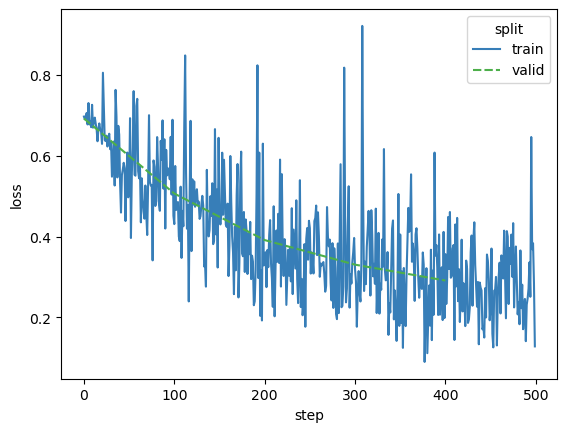

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

sns.lineplot(
    data=losses,
    x="step",
    y="loss",
    hue="split",
    style="split",
    palette=DEFAULT_SPLIT_COLORS
);

Reaching this stage, where you have a working model, a dataset, and training with decreasing loss, is a major milestone. The rest of this chapter focuses on improving and extending this foundation.

#### **Sanity Checking the Model**

Before we do anything more complicated, we should first check that the model has learned something sensible. One simple check is verifying that the trained model
behaves as expected on known DNA motifs. For example, from an online search, we can see that the CTCF transcription factor is known to prefer binding DNA sequences containing motifs similar CCACCAGGGGGCGC. Let’s construct the 200-base-long DNA string containing repeats of this motif and convert it to the one-hot encoded format that our model expects:

In [32]:
ctcf_motif_dna = "CCACCAGGGGGCGC" * 14 + "AAAA"
print("Length of CTCF motif-filled DNA string:", len(ctcf_motif_dna))

# We add the None here as a batch axis, since our model expects batched input.
ctcf_input = dna_to_one_hot(ctcf_motif_dna)[None, :]
ctcf_input.shape

Length of CTCF motif-filled DNA string: 200


(1, 200, 4)

We expect that the model will predict a very high probability of CTCF binding this sequence, since it’s packed with the relevant motif. Let’s check:

In [33]:
jax.nn.sigmoid(model.apply({"params": state.params}, ctcf_input))

Array([[0.9999964]], dtype=float32)

And this is indeed the case: the predicted probability of binding is very close to 1. This means the model has learned to identify this motif in the DNA sequence and associate it with CTCF binding.

Conversely, if we construct some pseudorandom DNA strings, the model should predict a relatively low probability of CTCF binding them:

In [34]:
random_dna_strings = [
  "A" * 200,
  "C" * 200,
  "G" * 200,
  "T" * 200,
  "ACGTACGT" * 25,
  "TCGATCGT" * 25,
  "TATACGCG" * 25,
  "CAGGCAGG" * 25,
]

probabilities = []

for random_dna_string in random_dna_strings:
    random_dna_input = dna_to_one_hot(random_dna_string)[None, :]

    probabilities.append(
      jax.nn.sigmoid(model.apply({"params": state.params}, random_dna_input))[0]
    )

probabilities

[Array([0.00139], dtype=float32),
 Array([0.00932247], dtype=float32),
 Array([0.00025015], dtype=float32),
 Array([0.0002728], dtype=float32),
 Array([0.13120522], dtype=float32),
 Array([0.01352851], dtype=float32),
 Array([0.08598638], dtype=float32),
 Array([0.0050515], dtype=float32)]

In [35]:
from dlfb.utils.restore import store

store(assets("dna/models/prototype"), state, metrics=losses.to_dict("records"))

As expected, these probabilities look relatively low, meaning that the CTCF protein is not likely to bind these sequences of random DNA. This completes a basic sanity check of our approach, but let’s dig a bit deeper into what this model has already learned about DNA sequences.

## **Increasing Complexity**

In this section, we will first apply ISM and input gradients to understand what model has learned better. These methods produce *contribution scores* (or *saliency maps*) that assign an importance value to each base in the DNA sequence.

Second, we will expand out prediction task from one TF to all 10 TFs in our dataset. This allows us to explore how model performance varies across TFs and how motif preferences differ between them.

After these two tasks, we'll come back to improving the model architecture itself.

### **Conducting In Silico Mutagenesis**

In ISM approach, the goal is to mutate all position and assess how it affects the model prediction. If prediction is worsen, that means the position is important if not, we can conclude that the position is not important.

Before making all possible mutations, let’s first check the effect of making just a single mutation. We’ll start by identifying a DNA sequence in the validation set that binds the CTCF protein (i.e., has a label of 1):

In [36]:
# The first positive example of a sequence that binds the transcription factor.
first_positive_index = np.argmax(valid_ds["labels"].flatten() == 1)

original_sequence = valid_ds["sequences"][first_positive_index].copy()
print(f'This sequence has label: {valid_ds["labels"][first_positive_index]}')

This sequence has label: [1]


Next, let’s examine what the model predicts for this unmodified sequence:

In [37]:
pred = nn.sigmoid(
  model.apply({"params": state.params}, original_sequence[None, :])
)
print(pred)

[[0.9011862]]


The original sequence has a predicted binding probability of 95.9%.

Now let’s create a single mutation at position 100. The original base is a G (encoded as [0, 0, 1, 0]), and we change it to a C (encoded as [0, 1, 0, 0]):

In [38]:
sequence = original_sequence.copy()
print(f"Original base at index 100: {sequence[100]}")

sequence[100] = np.array([0, 1, 0, 0])
print(f"Mutated base at index 100: {sequence[100]}")

Original base at index 100: [0 0 1 0]
Mutated base at index 100: [0 1 0 0]


In [39]:
pred_with_mutation = nn.sigmoid(
  model.apply({"params": state.params}, sequence[None, :])
)
pred_with_mutation

Array([[0.8174394]], dtype=float32)

After the mutation, the model’s predicted binding probability drops to 92.2%, a decrease of over 2.4%. This shows that even a single-base change at a sensitive
position can substantially impact the model’s output.

Now that we’ve observed how a single mutation can influence the prediction, let’s extend this approach to systematically mutate every position in the sequence. This
will give us a more global view of which bases matter most for the model’s prediction.

#### **Implementing *In Silico* Saturation Mutagenesis**

Here’s the basic plan for our implementation:

1. **Mutate:** Start with the original sequence. At each position, change the base to each of the other three possible DNA bases.
2. **Predict:** Run the model on each mutated sequence and record the predicted binding probability.
3. **Aggregate:** Collect all results to identify which mutations cause meaningful changes.

In [40]:
def generate_all_mutations(sequence: np.ndarray) -> np.ndarray:
    """Generate all possible single base mutations of a one-hot DNA sequence."""
    mutated_sequences = []
    for i in range(sequence.shape[0]):
        # At each position, one the four 'mutations' is the original base (no-op).
        for j in range(4):
            mutated_sequence = sequence.copy()
            mutated_sequence[i] = np.zeros(4)
            mutated_sequence[i][j] = 1
            mutated_sequences.append(mutated_sequence)
    sequences = np.stack(mutated_sequences)
    return sequences

mutated_sequences = generate_all_mutations(sequence=original_sequence.copy())
print(f"Shape of mutated sequences: {mutated_sequences.shape}")

Shape of mutated sequences: (800, 200, 4)


We now have 800 sequences: four variants for each of the 200 positions. Although only three of those per position are true mutations (since mutating, say, A to an A is a no-op), we include all four to simplify downstream logic.

We can now run predictions on all these mutated sequences in a single batch:

In [41]:
preds = nn.sigmoid(model.apply({"params": state.params}, mutated_sequences))

# Reshape to get the shape (sequence_length, dna_bases).
preds = preds.reshape((200, 4))

Let’s visualize the predicted binding probabilities for every mutated sequence:

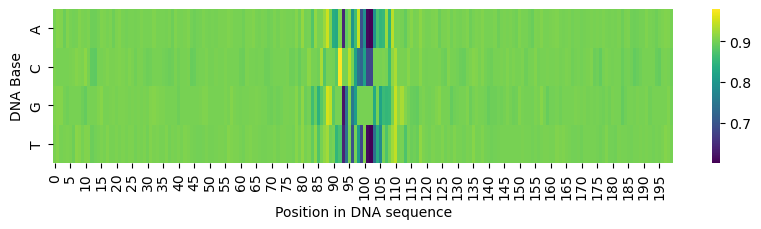

In [42]:
plt.figure(figsize=(10, 2))
sns.heatmap(preds.T, cmap="viridis", yticklabels=["A", "C", "G", "T"])
plt.xlabel("Position in DNA sequence")
plt.ylabel("DNA Base");

This shows us that:
* Most mutations don’t change the prediction much. The model predicts close to the original 97.8% probability of CTCF binding for sequences containing most
mutations.
* A central region does appear to significantly affect the binding prediction.

But what we really care about is how much each mutation changes the prediction. Let’s subtract the original (unmutated) predicted probability and center the color map at zero:

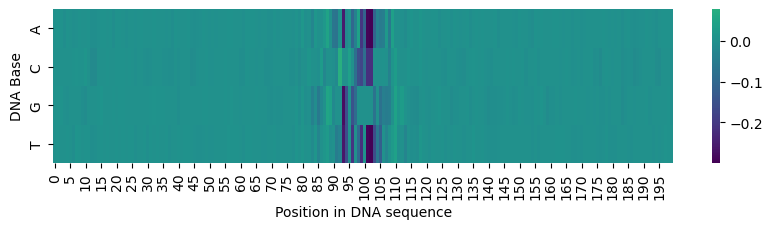

In [43]:
baseline_pred = nn.sigmoid(
  model.apply({"params": state.params}, original_sequence[None, :])
)
deltas = preds - baseline_pred

plt.figure(figsize=(10, 2))
sns.heatmap(deltas.T, center=0, cmap="viridis", yticklabels=["A", "C", "G", "T"])
plt.xlabel("Position in DNA sequence")
plt.ylabel("DNA Base");

Now the heatmap is clearer:
* Most positions are lighter, meaning their mutations have little effect.
* A few bases in the center are dark (decreased binding) or light (increased binding), showing meaningful influence.

We can quantify mutation effects using a helper function, `describe_change`. It allows us to have a look at the impact of mutating position 100 for all bases:

```python
def describe_change(
    idx, deltas: np.ndarray, sequence: np.ndarray, bases=["A", "C", "G", "T"]
) -> str:
    """Describe the effect of mutating one base to another."""
    seq_pos, base_idx = idx
    original_base = bases[np.argmax(sequence[seq_pos])]
    new_base = bases[base_idx]
    perc_delta = deltas[idx].item() * 100
    direction = "increase" if perc_delta >= 0 else "decrease"
    mutation = f"{original_base}→{new_base}"
    change = f"position {seq_pos} with {mutation} ({perc_delta:.2f}% {direction})"
    return change

```

In [44]:
from dlfb.dna.inspect import describe_change

# display([describe_change])

In [45]:
for i in range(4):
  print(describe_change((100, i), deltas, original_sequence))

position 100 with G→A (-11.17% decrease)
position 100 with G→C (-8.37% decrease)
position 100 with G→G (-0.00% decrease)
position 100 with G→T (0.50% increase)


Let’s also summarize the overall importance of each position in the DNA sequence by summing the absolute changes across all possible base mutations at each position. The result is visualized using `plot_binding_site` helper function, highlighting which regions the model considers most influential for its prediction:

```python
def plot_binding_site(panels, highlight: tuple[int, int] | None = None):
  """Plot a line plot and heatmap of contribution scores in a DNA sequence."""
  fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 3),
    gridspec_kw={"height_ratios": [1, 3]},
    sharex=True,
    constrained_layout=True,
  )

  ax1, ax2 = axes

  # Position-wise line plot.
  ax1.plot(panels["line"]["values"], c="black")
  ax1.set_ylabel(panels["line"]["label"])
  for spine in ax1.spines.values():
    spine.set_visible(False)
  ax1.set_xticks([])

  # Heatmap without colorbar.
  heatmap = sns.heatmap(
    panels["tiles"]["values"].T,
    ax=ax2,
    center=0,
    cbar=False,
    cmap="viridis",
    yticklabels=["A", "C", "G", "T"],
  )
  ax2.set_xlabel("Position in DNA sequence")
  ax2.set_ylabel("DNA Base")

  # Add shared vertical colorbar.
  cbar = fig.colorbar(
    heatmap.collections[0],
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
  )
  cbar.set_label(panels["tiles"]["label"])

  # Optional highlight region.
  if highlight:
    start, end = highlight
    rect = plt.Rectangle(
      xy=(start, 0),
      width=end - start,
      height=panels["tiles"]["values"].shape[1],
      linewidth=3,
      edgecolor="black",
      facecolor="none",
    )
    ax2.add_patch(rect)

  return fig

```

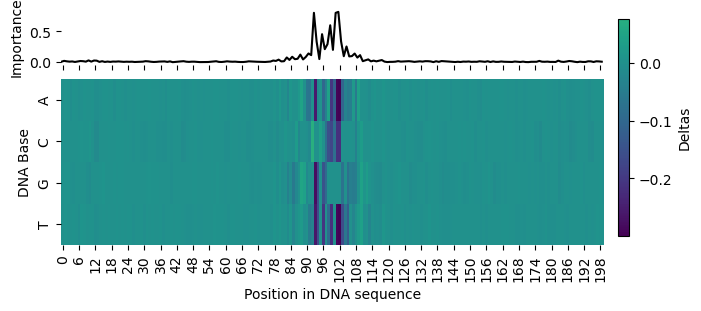

In [46]:
from dlfb.dna.inspect import plot_binding_site

importance = np.sum(np.abs(deltas), axis=1)
plot_binding_site(
  panels={
    "tiles": {"label": "Deltas", "values": deltas},
    "line": {"label": "Importance", "values": importance},
  },
);

In [47]:
for i in range(4):
  print(describe_change((102, i), deltas, original_sequence))

position 102 with G→A (-29.97% decrease)
position 102 with G→C (-21.82% decrease)
position 102 with G→G (-0.00% decrease)
position 102 with G→T (-29.96% decrease)


In [48]:
print("Largest increase comes from mutating position: ", np.argmax(np.max(deltas, axis=1)))
print("Largest decrease comes from mutating position: ", np.argmin(np.min(deltas, axis=1)))

Largest increase comes from mutating position:  92
Largest decrease comes from mutating position:  102


In [49]:
for i in range(4):
    print(describe_change((92, i), deltas, original_sequence))

for i in range(4):
    print(describe_change((102, i), deltas, original_sequence))

position 92 with G→A (0.48% increase)
position 92 with G→C (7.74% increase)
position 92 with G→G (-0.00% decrease)
position 92 with G→T (-3.28% decrease)
position 102 with G→A (-29.97% decrease)
position 102 with G→C (-21.82% decrease)
position 102 with G→G (-0.00% decrease)
position 102 with G→T (-29.96% decrease)


We can identify the most impactful mutations by ranking the values. In this case, the largest increase comes from mutating the base at position 92 with G→C (3.54% increase), and the biggest decrease comes from mutating the base at position 102 with G→T (-31.83% decrease).

#### **Verifying Motif Presence**

We can use FIMO (Find Individual Motif Occurences) from MEME suite to validate the region our model predicted as CTCF binding motif. But, before that we need to convert one-hot encoded arrays into DNA sequeces. This can be done using the following helper function:

```python
def one_hot_to_dna(one_hot_encoded: np.ndarray) -> str:
    """Convert one-hot encoded array back to DNA sequence."""
    one_hot_to_base = {
        (1, 0, 0, 0): "A",
        (0, 1, 0, 0): "C",
        (0, 0, 1, 0): "G",
        (0, 0, 0, 1): "T",
        (1, 1, 1, 1): "N",  # N represents any unknown or ambiguous base.
    }

    dna_sequence = "".join(
        one_hot_to_base[tuple(base)] for base in one_hot_encoded
    )
    return dna_sequence

In [50]:
from dlfb.dna.utils import one_hot_to_dna

# display([one_hot_to_dna])

In [51]:
print(one_hot_to_dna(original_sequence)[0:25], "...")

ACCCCAGGGTAGGGCCTATTGTATG ...


For CTCF, the known binding motif we used was CCACCAGGGGGCGC. When wesubmitted our sequence, FIMO reported a match to the CTCF motif (specifically, the subsequence GCCTCTGGGGGCGC, spanning positions 93 to 106) with a highly significant p-value of 2.6e-05, as shown in Figure 3-10:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="./images/figure_3_10.png" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 3.10</strong> How we used FIMO to search for the known CTCF binding motif within a 200 bp DNA sequence labeled as positive. Although transcription factor motifs are usually represented more flexibly using position weight matrices (PWMs), a simple string-based search for the canonical motif CCACCAGGGGGCGC offers a quick sanity check to confirm that the expected pattern is present in the sequence.
    </figcaption>
</figure>

Now, let's highlight position of motif region obtained from FIMO on our saliency map:

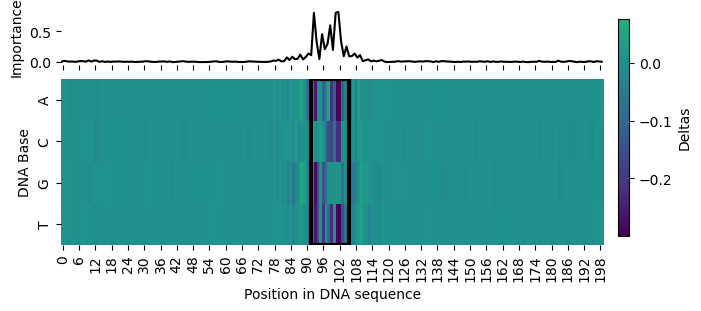

In [52]:
plot_binding_site(
  panels={
    "tiles": {"label": "Deltas", "values": deltas},
    "line": {"label": "Importance", "values": importance},
  },
  highlight=(92, 106),
);

As you can see, the motif returned by FIMO lines up almost exactly with the most mutation-sensitive region identified by our model through in silico mutagenesis. This alignment gives us confidence that the model has learned to recognize meaningful biological signal—in this case, a known CTCF binding motif—directly from sequence data.

#### **Implementing Input Gradients**

Input gradients serve as a fast, mathematically driven alternative to in silico mutagenesis (ISM) to identify which DNA bases most heavily influence the model's predictions.

The method uses JAX's auto-differentiation (`jax.grad`) to compute the derivative of the model’s predicted binding probability with respect to the one-hot encoded input sequence. This calculation yields a sensitivity matrix of the exact same shape as the input DNA sequence (e.g., $(200 \times 4)$). Unlike ISM, input gradients do not simulate actual physical mutations. Instead, they measure sensitivity to infinitesimal changes in base activations. Because of this mathematical abstraction, even a base that is already present (such as a G at a position that is already G) can display a highly active gradient, signaling that the model relies heavily on its presence.

Here are practical trade-offs of input gradients method:
* **Pros:** It is highly computationally efficient, requiring only a single backward pass rather than the hundreds of separate forward passes demanded by systematic saturation mutagenesis.
* **Cons:** The resulting saliency maps can be noisier and more abstract than ISM due to model nonlinearities and saturation effects.

Here is a helper function to compute gradients wrt to model inputs:

```python
@jax.jit
def compute_input_gradient(state, sequence):
    """Compute input gradient for a one-hot DNA sequence."""
    if len(sequence.shape) != 2:
        raise ValueError("Input must be a single one-hot encoded DNA sequence.")

    sequence = jnp.asarray(sequence, dtype=jnp.float32)[None, :]

    def predict(sequence):
        # We take the mean to ensure we have a single scalar to take the grad of.
        return jnp.mean(state.apply_fn({"params": state.params}, sequence))

    gradient = jax.grad(lambda x: predict(x))(sequence)
    return jnp.squeeze(gradient)

```

In [53]:
from dlfb.dna.utils import compute_input_gradient

# display([compute_input_gradient])

Let’s apply it to the same sequence we used for ISM and inspect the output:

In [54]:
input_gradient = compute_input_gradient(state, original_sequence)
input_gradient.shape

(200, 4)

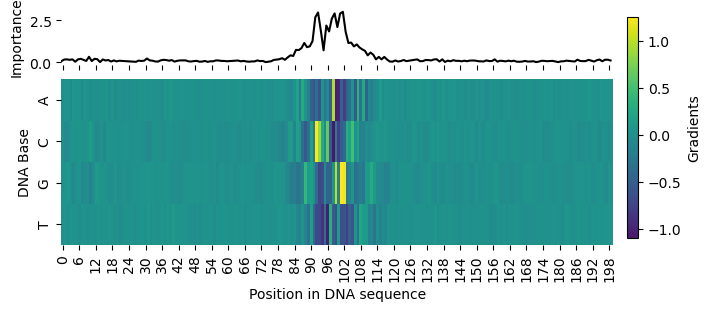

In [55]:
importance = np.sum(np.abs(input_gradient), axis=1)
plot_binding_site(
  panels={
    "tiles": {"label": "Gradients", "values": input_gradient},
    "line": {"label": "Importance", "values": importance},
  },
);

Central DNA sequence with high importance:  TGGCCTCTGGGGGCGCTCTG


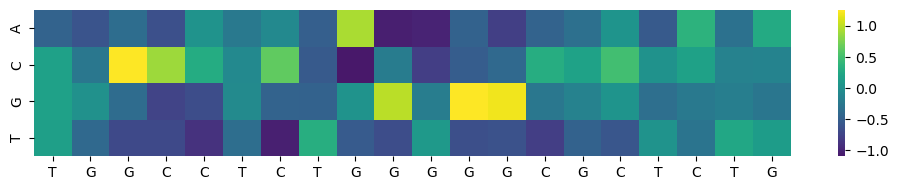

In [56]:
important_sequence = one_hot_to_dna(original_sequence)[90:110]
print("Central DNA sequence with high importance: ", important_sequence)

plt.figure(figsize=(10, 2))
sns.heatmap(
  input_gradient[90:110].T,
  cmap="viridis",
  center=0,
  xticklabels=important_sequence,
  yticklabels=["A", "C", "G", "T"],
)
plt.tight_layout();

Zoomed input gradients over the CTCF motif. In this close-up view of the region identified as important by input gradients, each cell shows how the model’s
predicted CTCF binding probability would change in response to a small increase in a specific base at a given position. Unlike ISM, even the base that is already present (e.g., G→G) can have a high gradient—indicating that the model is highly sensitive to that base and relies on it for its prediction. Strongly positive or negative values reflect positions where the model has learned a motif and is using it to assess CTCF binding.

Now, we extend our analysis to the first 10 sequences in the validation set that are labeled 1 (i.e., sequences that are known to bind CTCF), and visualize their input gradients using the following helper function:

```python
def plot_10_gradients(state, dataset, target_label, max_count=10):
    """Plot saliency maps for 10 sequences of a given label."""
    input_grads = [
        compute_input_gradient(state, sequence)
        for sequence in filter_sequences_by_label(dataset, target_label, max_count)
    ]
    fig, axes = plt.subplots(nrows=int(max_count / 2), ncols=2, figsize=(12, 6))
    for ax, input_grad in zip(axes.flatten(), input_grads):
        sns.heatmap(
        input_grad.T,
        cmap="viridis",
        center=0,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
        ax=ax,
        )
    plt.tight_layout()
    return fig


def filter_sequences_by_label(dataset, target_label, max_count):
    """Filter up to N sequences matching a target label."""
    sequences = []
    for i, label in enumerate(dataset["labels"]):
        if label == target_label:
        sequences.append(dataset["sequences"][i])
        if len(sequences) == max_count:
            break
    return sequences
```

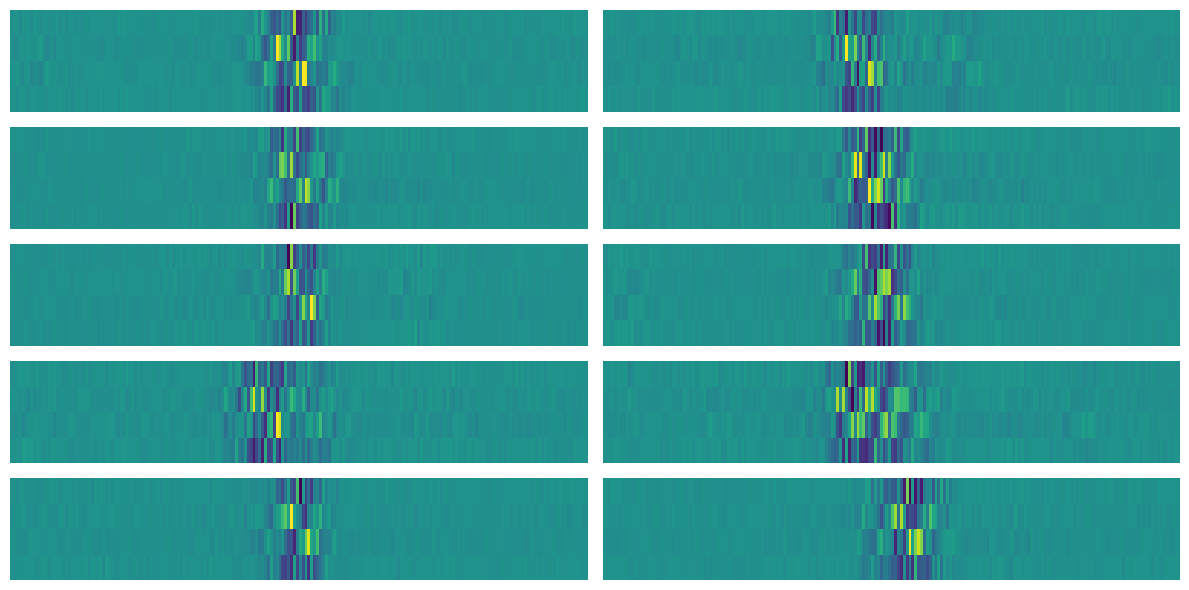

In [57]:
from dlfb.dna.inspect import plot_10_gradients

plot_10_gradients(state, valid_ds, target_label=1);

These gradients show a consistent central pattern across the examples, indicating that the model has likely learned a motif centered within the sequence. While the width of the important region varies slightly, the signal is strong and localized.

Let's run the analysis for negative sequences:

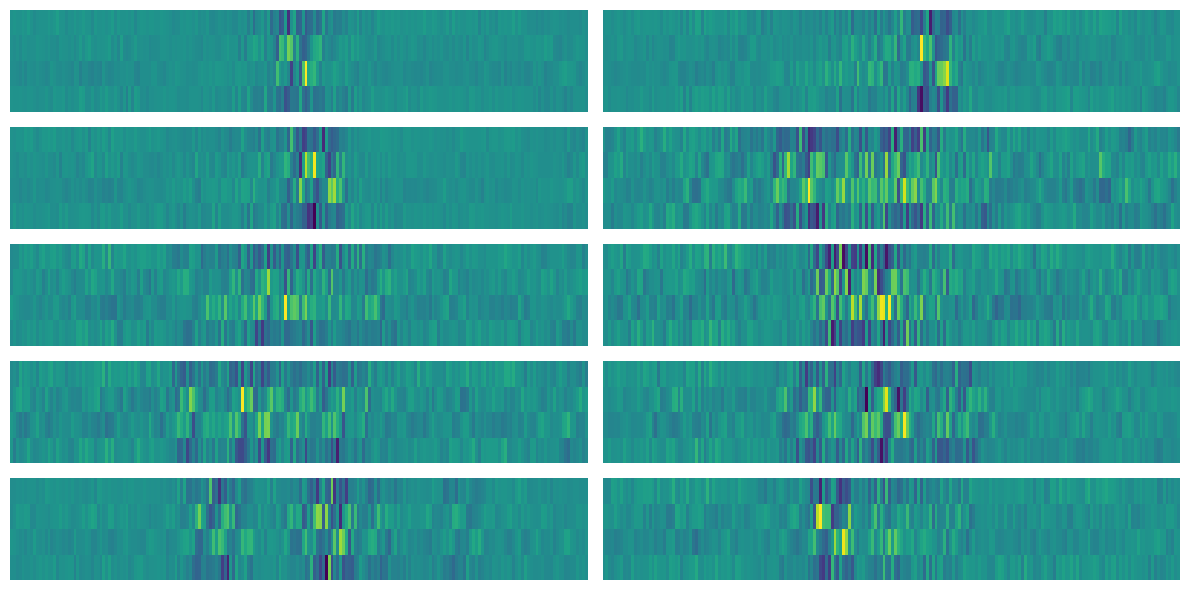

In [58]:
plot_10_gradients(state, valid_ds, target_label=0);

In the above plot, some sequences show a weaker but still present centered signal. Others display no clear motif or have diffuse scores spread across the entire sequence.

This variation makes sense given the way the dataset was constructed. While these sequences are labeled negative, they were carefully matched to positive examples in terms of chromatin accessibility. That means they also come from open chromatin regions and may still contain weak or partial motifs — or even motifs for other TFs. As a result, the model might still “attend” to the center of the sequence, even if it ultimately predicts no binding.

### **Modelling Multiple Transcription Factors**

Now that we’ve explored two complementary interpretation tools, ISM and input gradients, we’re in a better position to trust (and debug) what the model is learning. Let’s return to the modeling task and increase both the problem complexity and model capacity.

Let’s now increase the biological scope of our modeling by predicting binding for all 10 TFs in the dataset.

#### **Preparing a Multi-TF Dataset**

The dataset includes binding labels for the following 10 transcription factors:

In [59]:
transcription_factors = [
  "ARID3",
  "ATF2",
  "BACH1",
  "CTCF",
  "ELK1",
  "GABPA",
  "MAX",
  "REST",
  "SRF",
  "ZNF24",
]

Each of these TFs has its own distinct DNA-binding preference. These preferences are often conserved across species, and the role of each TF can be deeply rooted in specific cell type identity or developmental processes. Our task now is to train models that can automatically discover these motif patterns and accurately associate them with TF binding.

There are two common strategies for tackling this problem:

* **Multitask learning**: Train a single model to output one prediction per TF, potentially learning shared representations across tasks.
* **Single-task learning**: Train separate binary classification models for each TF independently.

In our case, the 10 TFs are not particularly closely related, and their binding preferences are quite distinct, ranging from insulator proteins like CTCF to general transcriptional regulators like MAX and neuron-specific factors like REST. Additionally, the dataset provides separate training sets for each TF, and the original paper trained them independently. Given these factors, we’ll follow a single-task learning approach: train 10 individual binary classification models, one per TF. 

#### **Defining a More Complex Model**

To scale up the project from predicting a single transcription factor (CTCF) to predicting binding across all 10 different TFs in the dataset, we introduce a more robust architecture. While keeping the same core convolutional structure, we incorporate three standard deep learning techniques to improve training stability and prevent overfitting:

* **Batch Normalization:** Added immediately after each convolutional layer to normalize activations across each batch. This stabilizes training, smooths the optimization landscape, and accelerates convergence.
* **Dropout Regularization:** Applied after the fully connected (dense) layers at a rate of 0.2. By randomly setting a portion of activations to zero during training, it prevents the model from relying too heavily on specific pathways, forcing it to learn more robust and redundant features.
* **Learning Rate Scheduling:** Replaces a fixed learning rate with a dynamic **cosine decay schedule** starting at 0.001. The learning rate gradually decreases over the 1,000 training steps, encouraging rapid parameter exploration early on and highly stable convergence toward the end.


$$\eta_t = \eta_{\text{min}} + \frac{1}{2}(\eta_{\text{max}} - \eta_{\text{min}})\left(1 + \cos\left(\frac{t}{T_{\text{max}}}\pi\right)\right)$$

These upgrades prepare the network to handle the more complex and noisy signals associated with diverse TF binding preferences.

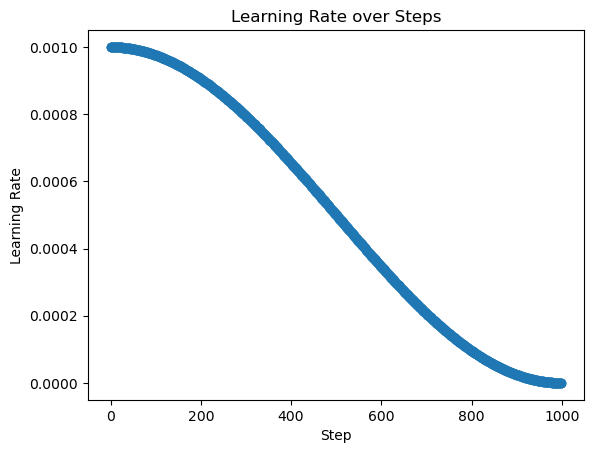

In [60]:
num_steps = 1000

scheduler = optax.cosine_decay_schedule(
  init_value=0.001,
  decay_steps=num_steps,  # How long to decay over.
)
learning_rates = [scheduler(i) for i in range(num_steps)]

plt.scatter(range(num_steps), learning_rates)
plt.title("Learning Rate over Steps")
plt.ylabel("Learning Rate")
plt.xlabel("Step");

Even though our dataset and architecture are fairly simple, these additions should help improve training stability and model generalization across the expanded set of transcription factor tasks.

Let’s now implement the updated model definition:

```python
class TrainStateWithBatchNorm(TrainState):
    """TrainState with batch norm stats and RNG key."""

    batch_stats: dict | None
    key: jax.Array


class ConvModelV2(nn.Module):
  """CNN with batch norm and dropout for binary classification."""

  conv_filters: int = 64  # Number of filters for conv layers.
  kernel_size: tuple[int] = (10,)  # Kernel size for 1D conv layers.
  dense_units: int = 128  # Units in first dense fully connected layer.
  dropout_rate: float = 0.2  # Proportion of dense neurons to randomly drop out.

  @nn.compact
  def __call__(self, x, is_training: bool = True):
    # First convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.BatchNorm(use_running_average=not is_training)(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Second convolutional layer.
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.BatchNorm(use_running_average=not is_training)(x)
    x = nn.gelu(x)
    x = nn.max_pool(x, window_shape=(2,), strides=(2,))

    # Flatten the values before passing them to the dense layers.
    x = x.reshape((x.shape[0], -1))

    # First dense layer.
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)
    x = nn.Dropout(rate=self.dropout_rate, deterministic=not is_training)(x)

    # Second dense layer.
    x = nn.Dense(self.dense_units // 2)(x)
    x = nn.gelu(x)
    x = nn.Dropout(rate=self.dropout_rate, deterministic=not is_training)(x)

    # Output layer (single unit for binary classification).
    return nn.Dense(1)(x)

  def create_train_state(self, rng: jax.Array, dummy_input, tx):
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init, rng_dropout = jax.random.split(rng, 3)
    # variables = self.init(rng_init, dummy_input)
    variables = self.init(
            rng_init,
            dummy_input,
            is_training=False
        )
    state = TrainStateWithBatchNorm.create(
      apply_fn=self.apply,
      tx=tx,
      params=variables["params"],
      batch_stats=variables.get("batch_stats", {}),
      key=rng_dropout,
    )
    return state
```

In [61]:
from dlfb.dna.model import ConvModelV2

# display([ConvModelV2])

Our `ConvModelV2` implementation is starting to get a bit long and repetitive. Later in the chapter, we’ll address this by refactoring out the repeated logic into `ConvBlock` and `DenseBlock` components to make the model definition more concise and modular.

For now, we have all the pieces needed to create the training state:

In [62]:
rng = jax.random.PRNGKey(42)
rng, rng_init, rng_train = jax.random.split(rng, 3)

state = ConvModelV2().create_train_state(
  rng=rng_init, dummy_input=batch["sequences"], tx=optax.adam(scheduler)
)

The training step looks fairly similar to what we’ve seen before, but now it needs to handle both dropout and batch normalization.

**One small additional change:** the loss function is defined directly inside train_step. This is often done for readability and encapsulation, especially when the loss depends on extra mutable model state (like `batch_stats`) or dropout, both of which are now required in the forward pass:

```python
@jax.jit
def train_step(state, batch, rng_dropout: jax.Array):
    """Run a training step and update parameters."""

    def calculate_loss(params, batch):
        """Make predictions on batch and compute binary cross-entropy loss."""
        logits, updates = state.apply_fn(
        {"params": params, "batch_stats": state.batch_stats},
        x=batch["sequences"],
        is_training=True,
        rngs={"dropout": rng_dropout},
        mutable=["batch_stats"],
        )

        loss = optax.sigmoid_binary_cross_entropy(logits, batch["labels"]).mean()

        return loss, updates

    grad_fn = jax.value_and_grad(calculate_loss, has_aux=True)
    (loss, updates), grads = grad_fn(state.params, batch)
    state = state.apply_gradients(grads=grads)
    state = state.replace(batch_stats=updates["batch_stats"])

    metrics = {"loss": loss}

    return state, metrics
    
```

In [63]:
from dlfb.dna.train import train_step

# display([train_step])

To confirm that everything is wired up correctly, we can overfit to a single batch, that is, run a few steps on the same batch and check that the loss decreases:

In [64]:
# Overfit on one batch.
for i in range(5):
  rng, rng_dropout = jax.random.split(rng, 2)
  state, metrics = train_step(state, batch, rng_dropout)
  print(f"Step {i} loss: {metrics['loss']}")

Step 0 loss: 0.6712766885757446
Step 1 loss: 0.4863378405570984
Step 2 loss: 0.33067917823791504
Step 3 loss: 0.18210084736347198
Step 4 loss: 0.05704241245985031


Looks good: the loss decreases quickly. This indicates the model is capable of fitting the data. However, loss alone isn’t the best way to evaluate classification models. We want to monitor additional metrics like accuracy and the area under the ROC curve (auROC). We compute these in an evaluation step:

```python
from sklearn.metrics import accuracy_score, roc_auc_score

def eval_step(state, batch):
    """Evaluate model on a single batch."""
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        x=batch["sequences"],
        is_training=False,
        mutable=False,
    )
    loss = optax.sigmoid_binary_cross_entropy(logits, batch["labels"]).mean()
    metrics = {
        "loss": loss.item(),
        **compute_metrics(batch["labels"], logits),
    }
    return metrics


def compute_metrics(y_true: np.ndarray, logits: np.ndarray):
    """Compute accuracy and auROC for model predictions."""
    metrics = {
        "accuracy": accuracy_score(y_true, nn.sigmoid(logits) >= 0.5),
        "auc": roc_auc_score(y_true, logits).item(),
    }
    return metrics

````

In [65]:
from dlfb.dna.train import eval_step

# display([eval_step, compute_metrics])

Note that since scikit-learn functions are not JAX compatible, the evaluation step is not decorated with `@jax.jit`. 

Let’s see the output of running eval_step:

In [66]:
# Evaluate the batch.
metrics = eval_step(state, batch)
print(metrics)

{'loss': 0.43473032116889954, 'accuracy': 0.90625, 'auc': 1.0}


Now that we’ve implemented the training and evaluation steps, let’s define a full training loop. The `train` function takes an initialized model state, training and validation datasets, and a few configuration parameters:

```python
def train(
    state: TrainStateWithBatchNorm,
    rng: jax.Array,
    dataset_splits: dict[str, tf.data.Dataset],
    num_steps: int,
    eval_every: int = 100,
    ) -> tuple[TrainStateWithBatchNorm, Any]:
    """Train a model and log metrics over steps."""
    metrics = MetricsLogger()
    train_batches = dataset_splits["train"].as_numpy_iterator()

    steps = tqdm(range(num_steps))  # Steps with progress bar.
    for step in steps:
        steps.set_description(f"Step {step + 1}")

        rng, rng_dropout = jax.random.split(rng, 2)
        train_batch = next(train_batches)
        state, batch_metrics = train_step(state, train_batch, rng_dropout)
        metrics.log_step(split="train", **batch_metrics)

        if step % eval_every == 0:
            for eval_batch in dataset_splits["valid"].as_numpy_iterator():
                batch_metrics = eval_step(state, eval_batch)
                metrics.log_step(split="valid", **batch_metrics)
            metrics.flush(step=step)

        steps.set_postfix_str(metrics.latest(["loss"]))

    return state, metrics.export()

```

In [67]:
from dlfb.dna.train import train

# display([train])

Since we’re training one model per TF, we’ll use a utility function to load datasets split by TF name:

```python
def load_dataset_splits(
    path, transcription_factor, batch_size: int | None = None
):
    """Load TF dataset splits (train, valid, test) as TensorFlow datasets."""
    dataset_splits = {}
    for split in ["train", "valid", "test"]:
        dataset = load_dataset(
        sequence_db=f"{path}/{transcription_factor}_{split}_sequences.csv"
        )
        ds = convert_to_tfds(dataset, batch_size, is_training=(split == "train"))
        dataset_splits.update({split: ds})
    return dataset_splits

```

This function loads training, validation, and test splits for the given `transcription_factor` and converts them into TensorFlow datasets ready for batching.

In [68]:
from dlfb.dna.dataset import load_dataset_splits

# display([load_dataset_splits])

We now have everything in place to train one model per TF:

In [69]:
prefix = assets("dna/datasets")
tf_metrics = {}

# Train one model per transcription factor.
for transcription_factor in transcription_factors:
    # Load data for this TF.
    dataset_splits = load_dataset_splits(
    assets("dna/datasets"), transcription_factor, batch_size
    )
    rng = jax.random.PRNGKey(42)
    rng, rng_init, rng_train = jax.random.split(rng, 3)
    dummy_batch = next(dataset_splits["train"].as_numpy_iterator())["sequences"]

    # Create train state.
    state = ConvModelV2().create_train_state(
      rng=rng_init,
      dummy_input=dummy_batch,
      tx=optax.adam(scheduler),
    )

    # Train the model.
    _, metrics = train(
        state=state,
        rng=rng_train,
        dataset_splits=dataset_splits,
        num_steps=num_steps,
        eval_every=100,
        store_path=assets(f"dna/models/{transcription_factor}"),
        )

    # Store metrics.
    tf_metrics.update({transcription_factor: metrics})

With training complete, let’s take a look at just CTCF transcription factor performance:

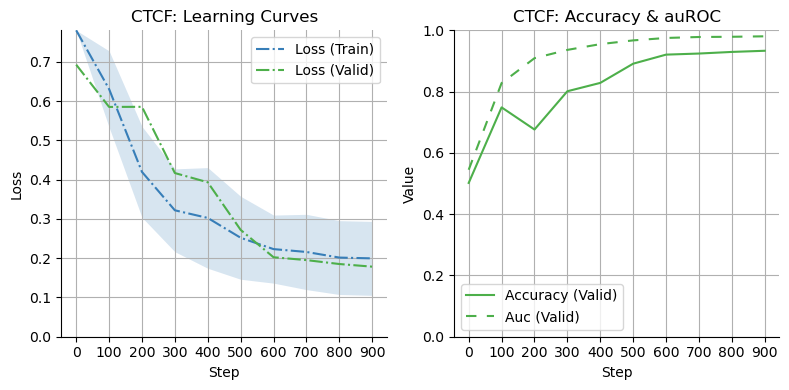

In [70]:
from dlfb.dna.inspect import plot_learning

tf = "CTCF"
plot_learning(tf_metrics[tf], tf);

Our model performs well on predicting whether CTCF binds a given DNA sequence, with training and validation losses decreasing and validation auROC approaching a perfect score of 1.0—consistent with the fact that CTCF is relatively easy to predict compared to some of the other TFs.

Let’s now visualize the training curves across all 10 TFs. We first process the logged metrics:

In [71]:
from dlfb.utils.metric_plots import to_df

# Extract metrics logged per transcription factor.
tf_df = []
for tf, metrics in tf_metrics.items():
    tf_df.append(to_df(metrics).assign(TF=tf))
tf_df = pd.concat(tf_df)

In [72]:
test = tf_df[(tf_df["metric"] == "auc") & (tf_df["split"] == "valid")]
test.groupby("TF")["mean"].max().index.tolist()

['ARID3',
 'ATF2',
 'BACH1',
 'CTCF',
 'ELK1',
 'GABPA',
 'MAX',
 'REST',
 'SRF',
 'ZNF24']

In [73]:
# Determine order of best performance.
auc_df = tf_df[(tf_df["metric"] == "auc") & (tf_df["split"] == "valid")]
max_auc_by_tf = auc_df.groupby("TF")["mean"].max()
tf_order = max_auc_by_tf.sort_values(ascending=False).index.tolist()
tf_df["TF"] = pd.Categorical(tf_df["TF"], categories=tf_order, ordered=True)

We can then visualize their learning curves sorted by auROC performance (best-performing TFs are first):

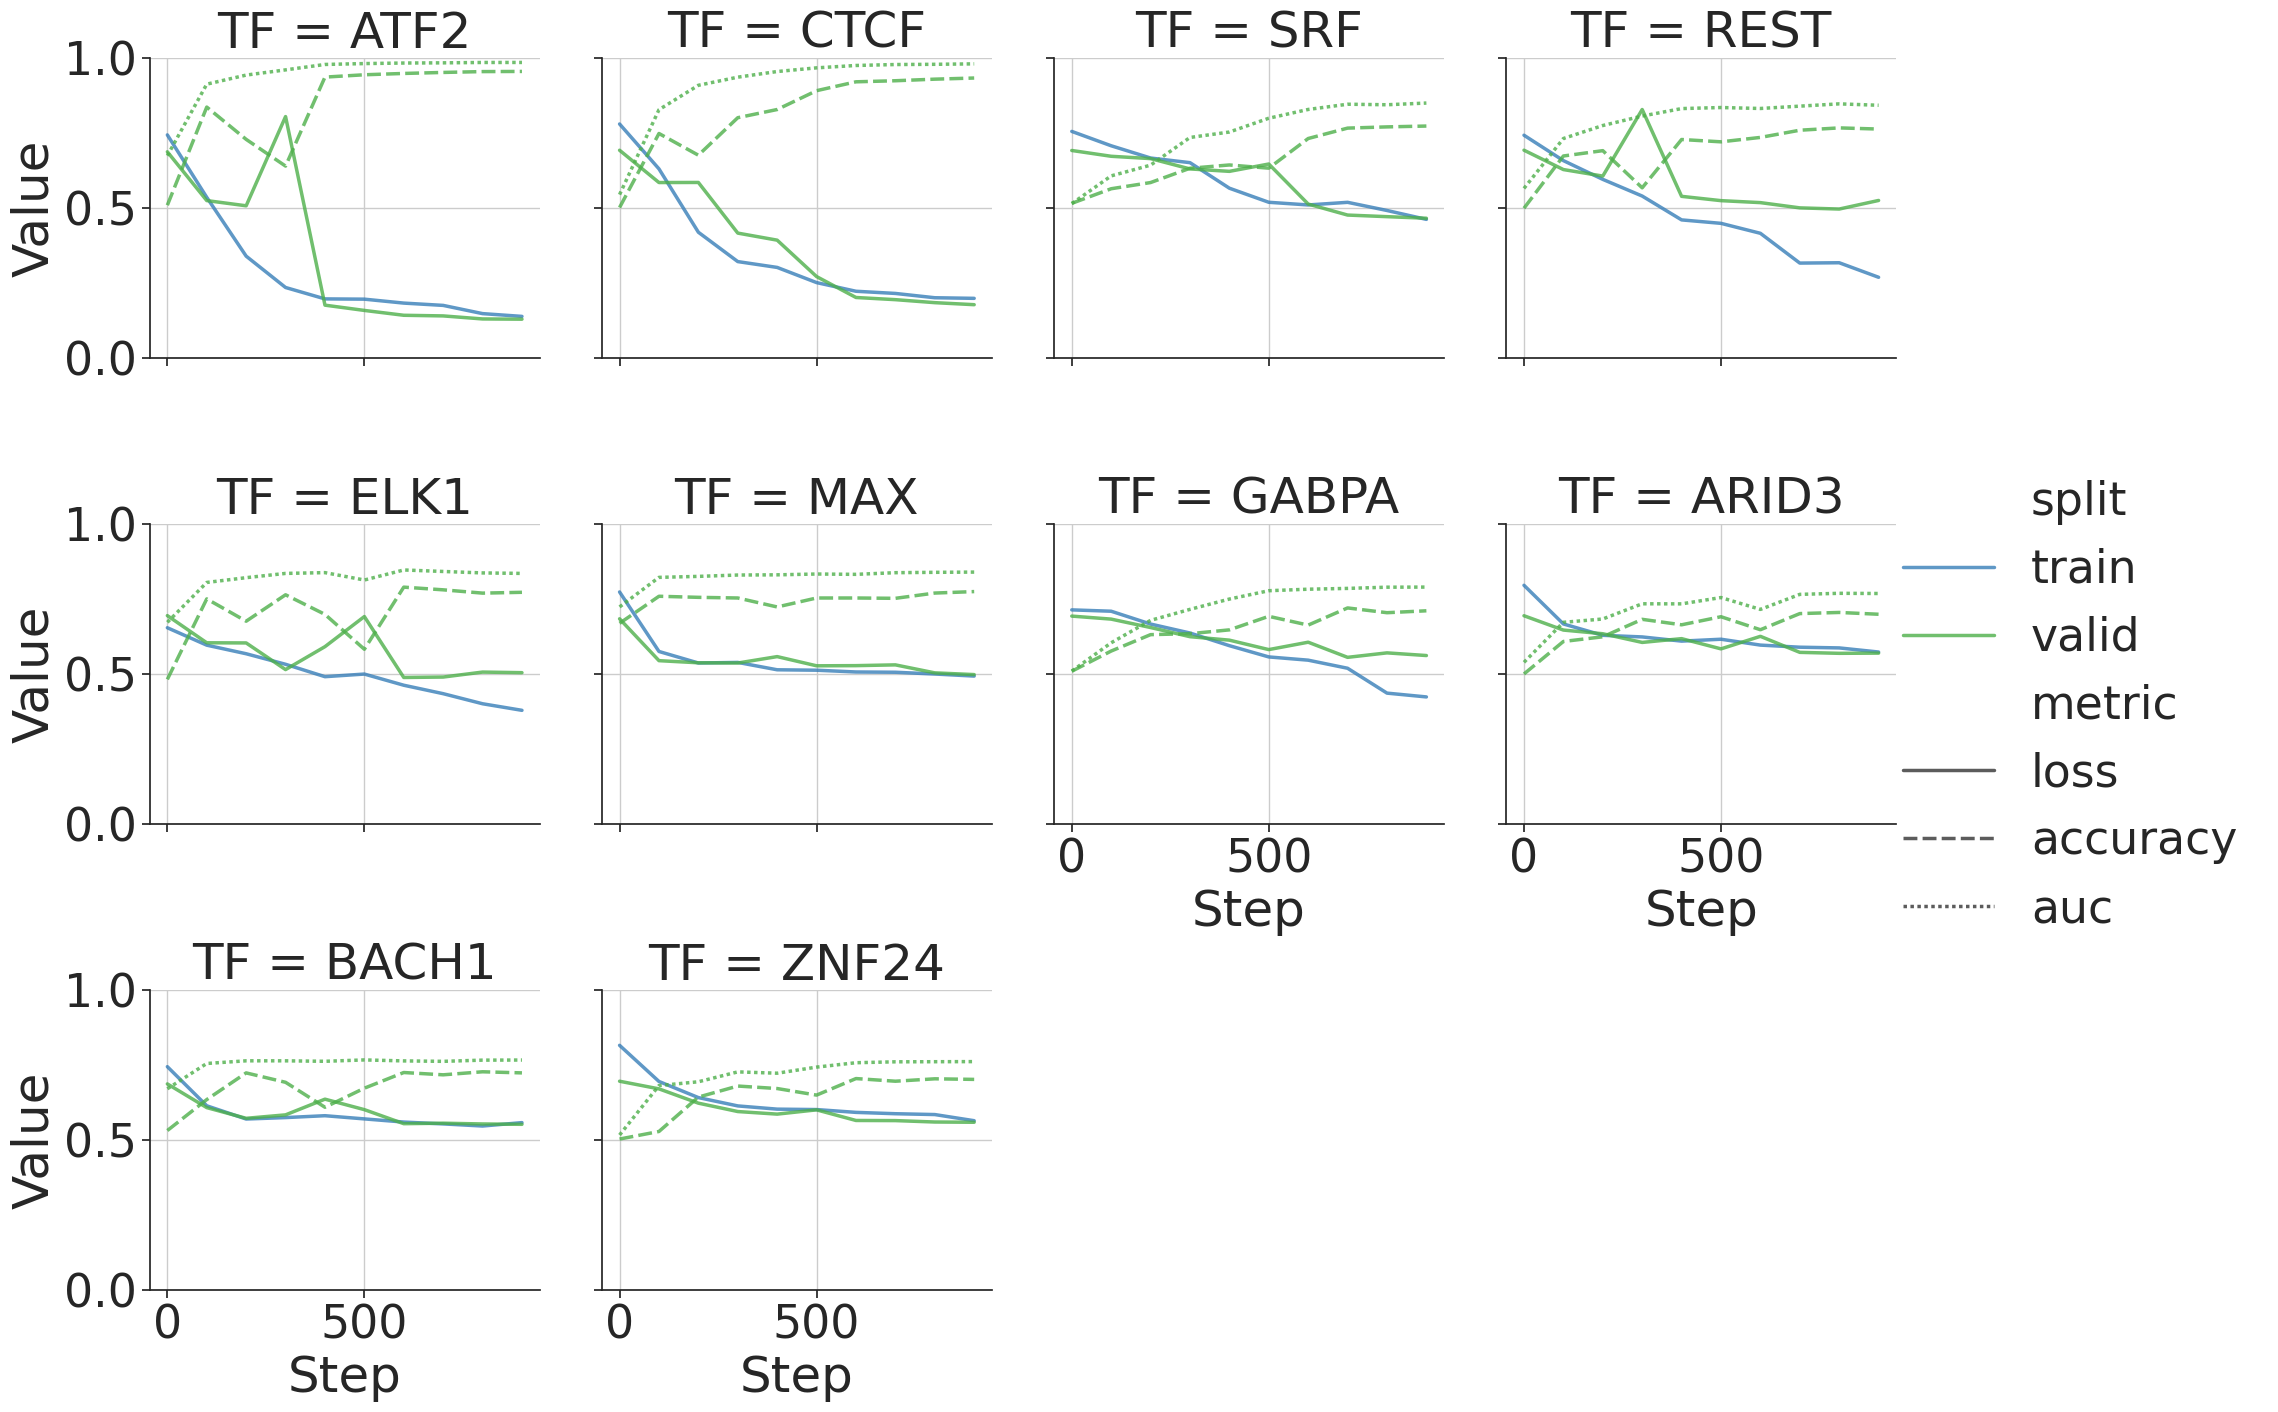

In [74]:
sns.set_context("notebook", font_scale=3, rc={"lines.linewidth": 2.5})
sns.set_style("ticks", {"axes.grid": True})
g = sns.relplot(
    data=tf_df,
    x="round",
    y="mean",
    hue="split",
    style="metric",
    kind="line",
    col="TF",
    col_order=tf_order,
    col_wrap=4,
    alpha=0.8,
    palette=DEFAULT_SPLIT_COLORS,
    dashes=True,
)
g.set_axis_labels("Step", "Value")
g.set(ylim=(0, 1));

Since our dataset comes from a published benchmark, we can directly compare our model’s results to those reported in the original paper. The following are key takeaways from the paper’s figure:
* CTCF and ATF2 are the most predictable TFs, with both one-hot and pretrained models achieving auROC scores above 0.95. These TFs have strong, conserved binding motifs that are easy for models to learn.
* REST, MAX, and ELK1 show intermediate difficulty, with auROCs around 0.83 to 0.85.
* ZNF24, BACH1, ARID3, and GABPA tend to be more difficult, with auROCs hovering in the 0.75 to 0.80 range.

Let’s now see how our own models compare. The following prints the peak validation auROC achieved by our CNNs trained independently for each TF:

In [75]:
print(max_auc_by_tf.sort_values(ascending=False))

TF
ATF2     0.985182
CTCF     0.980479
SRF      0.849944
REST     0.847251
ELK1     0.846878
MAX      0.839834
GABPA    0.789892
ARID3    0.769149
BACH1    0.767122
ZNF24    0.761506
Name: mean, dtype: float64


Our results closely mirror the rankings and scores from the paper—especially in terms of which TFs are easier or harder to predict. This consistency offers reassuring
external validation that our training setup is functioning correctly and our models are learning something meaningful.

#### **Why Are Some TFs Harder to Model Than Others?**

* **Motif Strength and Conservation:** Easy-to-predict TFs (such as CTCF and ATF2) bind to well-defined, highly conserved motifs that produce strong, consistent signals in the DNA. Harder TFs (such as ZNF24, ARID3, or BACH1) are much more complex because they may bind weakly or recognize flexible, degenerate motifs, which significantly weakens the sequence-to-binding signal.
* **Dependency on Contextual Cues:** Harder TFs often rely on subtle biological context to bind, such as chromatin accessibility, motif spacing, or the presence of cofactors. 
* **Sequence Window Constraints:** The simplified model in this chapter only looks at 200 base pairs of sequence. In living cells, TF binding depends on a much broader genomic and epigenetic context, including chromatin state and long-range interactions, though some of these signals are still partially encoded in local DNA patterns.

---

## **Advanced Techniques**

Before we extend our model, we refactor its architecture into reusable building blocks to make the code read easier and maintain well. To do that, we will modularize the convolutional and MLP layers into two helper modules called `ConvBlock` and `MLPBlock`:

```python
class ConvBlock(nn.Module):
  """Convolutional block with batch norm, GELU and max pooling."""

  conv_filters: int
  kernel_size: tuple[int]
  pool_size: int

  @nn.compact
  def __call__(self, x, is_training: bool = True):
    x = nn.Conv(
      features=self.conv_filters, kernel_size=self.kernel_size, padding="SAME"
    )(x)
    x = nn.BatchNorm(use_running_average=not is_training)(x)
    x = nn.gelu(x)
    x = nn.max_pool(
      x, window_shape=(self.pool_size,), strides=(self.pool_size,)
    )
    return x


class MLPBlock(nn.Module):
  """Dense + GELU + dropout block."""

  dense_units: int
  dropout_rate: float = 0.0

  @nn.compact
  def __call__(self, x, is_training: bool = True):
    x = nn.Dense(self.dense_units)(x)
    x = nn.gelu(x)
    x = nn.Dropout(rate=self.dropout_rate, deterministic=not is_training)(x)
    return x

```

In [86]:
from dlfb.dna.model import ConvBlock, MLPBlock

# display([ConvBlock, MLPBlock])

With these reusable blocks in place, we can now define a more compact and configurable model architecture:

```python
class ConvTransformerModel(nn.Module):
  """Model combining CNN, transformer, and MLP blocks."""

  num_conv_blocks: int = 2
  conv_filters: int = 64
  kernel_size: tuple[int] = (10,)
  num_mlp_blocks: int = 2
  dense_units: int = 128
  dropout_rate: float = 0.2  # Global.
  num_transformer_blocks: int = 0
  num_transformer_heads: int = 8
  transformer_dense_units: int = 64

  @nn.compact
  def __call__(self, x, is_training: bool = True):
    for _ in range(self.num_conv_blocks):
      x = ConvBlock(
        conv_filters=self.conv_filters,
        kernel_size=self.kernel_size,
        pool_size=2,
      )(x, is_training)

    for i in range(self.num_transformer_blocks):
      x = TransformerBlock(
        num_heads=self.num_transformer_heads,
        dense_units=self.transformer_dense_units,
        dropout_rate=self.dropout_rate,
      )(x, is_training)

    x = x.reshape((x.shape[0], -1))

    for i in range(self.num_mlp_blocks):
      x = MLPBlock(
        dense_units=self.dense_units // (i + 1), dropout_rate=self.dropout_rate
      )(x, is_training)

    return nn.Dense(1)(x)

  def create_train_state(self, rng: jax.Array, dummy_input, tx):
    """Initializes model parameters and returns a train state for training."""
    rng, rng_init, rng_dropout = jax.random.split(rng, 3)
    variables = self.init(rng_init, dummy_input)
    state = TrainStateWithBatchNorm.create(
      apply_fn=self.apply,
      tx=tx,
      params=variables["params"],
      batch_stats=variables["batch_stats"],
      key=rng_dropout,
    )
    return state

```

In [87]:
from dlfb.dna.model import ConvTransformerModel

# display([ConvTransformerModel], hide=[ConvTransformerModel.create_train_state])

This architecture supports optional transformer blocks inserted between the convolutional feature extractors and the MLP classifier. There is alos a `TransformerBlock`, which we’ll explore next.

### **Adding Self-attention and Transformer Blocks**

Our final architecture combines convolutional layers with transformer blocks. While convolutional layers are excellent at extracting local motif-like patterns from DNA, transformer blocks can capture long-range dependencies, patterns that span larger regions of the sequence. These two types of layers are highly complementary.

>**Note:** In our case, the sequences are relatively short (just 200 base pairs), so the benefits of long-range attention may be modest. However, attention mechanisms become increasingly useful as input length increases. For longer genomic contexts, such as full gene bodies, or interactions between potentially distant regulatory elements such as promoter and enhancer sequences, transformers can integrate signals across a broader range than is possible with fixed-size convolutional kernels.

Flax includes a built-in `SelfAttention` module, which we can use as the foundation for our TransformerBlock:

```python
class TransformerBlock(nn.Module):
    """Transformer block with self-attention and MLP."""

    num_heads: int = 8
    dense_units: int = 64
    dropout_rate: float = 0.2

    @nn.compact
    def __call__(self, x, is_training: bool = True):
        # Self-attention with layer norm.
        residual = x
        x = nn.LayerNorm()(x)
        x = nn.SelfAttention(num_heads=self.num_heads)(x)
        x += residual

        # Feedforward block.
        residual = x
        x = nn.LayerNorm()(x)
        x = nn.Dense(self.dense_units)(x)
        x = nn.gelu(x)
        x = nn.Dropout(rate=self.dropout_rate)(x, deterministic=not is_training)
        x = nn.Dense(self.dense_units)(x)  # No GELU after this Dense.
        x += residual
        return x

```

In [88]:
from dlfb.dna.model import TransformerBlock

# display([TransformerBlock])

A few notes on this design:

* **Self-attention**: The core operation is `nn.SelfAttention`, which enables each position in the sequence to attend to every other position, capturing dependencies across the input.
* **Residual connections**: The skip connections help stabilize training by allowing gradients to flow more easily through deep architectures.
* **Layer normalization**: Transformers typically use layer norm rather than batch norm, as it tends to be more stable for sequence-based models and is invariant to batch size.
* **Position information**: In our current setup, we omit explicit positional encodings, this is a simplification that may be acceptable for short sequences (e.g., 200 bp), where the relative arrangement of motifs can still be learned through the convolutional layers preceding attention. For longer inputs or if attention is applied very early, consider adding learned or sinusoidal positional encodings.

This modular `TransformerBlock` can now be optionally included between convolutional and MLP layers in our `ConvTransformerModel`.

### **Defining Various Model Architectures**

Now that our model is modular, we can experiment with different architectural settings to understand their impact on performance better. This kind of architectural exploration is common when tuning deep learning models. There’s rarely a single obvious “best” model, and trying multiple variants can reveal helpful insights.

In the following code, we define several models with different settings:

In [79]:
models = {
  # Our standard 2-layer CNN with dropout and MLP.
  "baseline": ConvTransformerModel(),
  # Ablations: Remove or reduce certain components.
  # Only a single convolutional block.
  "single_conv_only": ConvTransformerModel(
    num_conv_blocks=1, num_transformer_blocks=0, num_mlp_blocks=0
  ),
  # Reduced capacity by lowering conv filters.
  "fewer_conv_channels": ConvTransformerModel(conv_filters=8),
  # Drop the MLP layers to test if they help.
  "remove_MLP": ConvTransformerModel(num_mlp_blocks=0),
  # Potential improvements: Add more expressive capacity.
  # Add a transformer block after convolutions.
  "add_one_transformer_block": ConvTransformerModel(num_transformer_blocks=1),
  # Stack two transformer blocks.
  "add_two_transformer_block": ConvTransformerModel(num_transformer_blocks=2),
}

To test these variants, we’ll focus on the most difficult TF from our earlier results: ZNF24, which achieved a peak validation auROC of ~0.76 in our initial model. This makes it a great candidate to explore whether architectural improvements can lead to better predictive performance.

### **Sweeping Over the Different Models**

With all our model components now modularized, we can easily run systematic experiments to compare architectural choices. We’ll train several model variants, ranging from simpler ablations to transformer-enhanced architectures, on the most challenging TF in our benchmark: ZNF24. This allows us to explore which components help or hurt performance on a relatively
difficult task.

With all of this in place, we can train the different models in the model dict:

In [ ]:
# Train and evaluate multiple model architectures on the ZNF24 dataset.
transcription_factor = "ZNF24"
dataset_splits = load_dataset_splits(
  assets("dna/datasets"), transcription_factor, batch_size
)

# Prepare a dummy input for model initialization.
dummy_input = next(dataset_splits["train"].as_numpy_iterator())["sequences"]

# Initialize PRNGs.
rng = jax.random.PRNGKey(42)
rng, rng_init, rng_train = jax.random.split(rng, 3)

# Dictionary to store metrics for each model variant.
model_metrics = {}

# Train each model variant and store its metrics.
for name, model in models.items():
    state = model.create_train_state(
      rng=rng_init,
      dummy_input=dummy_input,
      tx=optax.adamw(
        optax.cosine_decay_schedule(
          init_value=learning_rate,
          decay_steps=num_steps,
        )
      ),
    )
    _, metrics = train(
      state=state,
      rng=rng_train,
      dataset_splits=dataset_splits,
      num_steps=num_steps,
      eval_every=100,
      store_path=assets(f"dna/models/{name}"),
    )
    model_metrics.update({name: metrics})

After training each model, we extract logged metrics over training time and visualize the results:

In [81]:
# Extract metrics logged per transcription factor.
model_df = []
for model, metrics in model_metrics.items():
  model_df.append(to_df(metrics).assign(model=model))
model_df = pd.concat(model_df)

# Determine order of best performance.
auc_df = model_df[
  (model_df["metric"] == "auc") & (model_df["split"] == "valid")
]
max_auc_by_model = auc_df.groupby("model")["mean"].max()
model_order = max_auc_by_model.sort_values(ascending=False).index.tolist()
model_df["model"] = pd.Categorical(
  model_df["model"], categories=model_order, ordered=True
)

With this code, we can plot our learning curves and metrics over time:

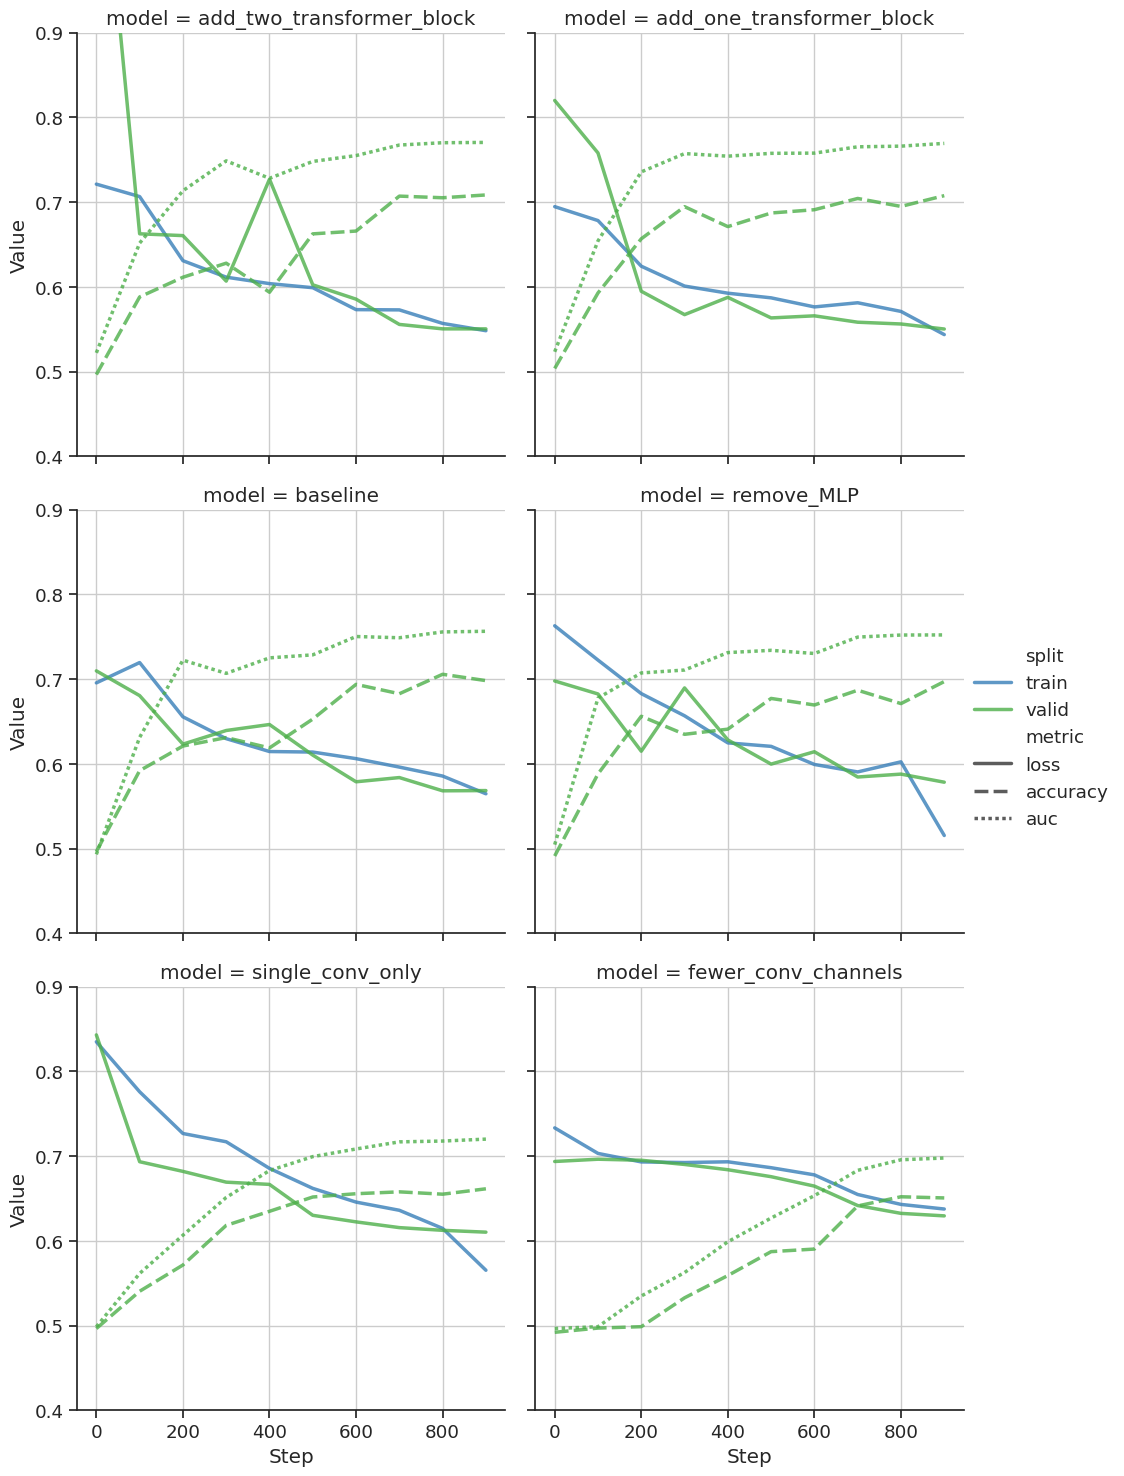

In [82]:
sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 2.5})
sns.set_style("ticks", {"axes.grid": True})
g = sns.relplot(
  data=model_df,
  x="round",
  y="mean",
  hue="split",
  style="metric",
  kind="line",
  col="model",
  col_order=model_order,
  col_wrap=2,
  alpha=0.8,
  palette=DEFAULT_SPLIT_COLORS,
  dashes=True,
)
g.set_axis_labels("Step", "Value")
g.set(ylim=(0.4, 0.9));

To better isolate model differences, we can plot just the validation auROC over time:

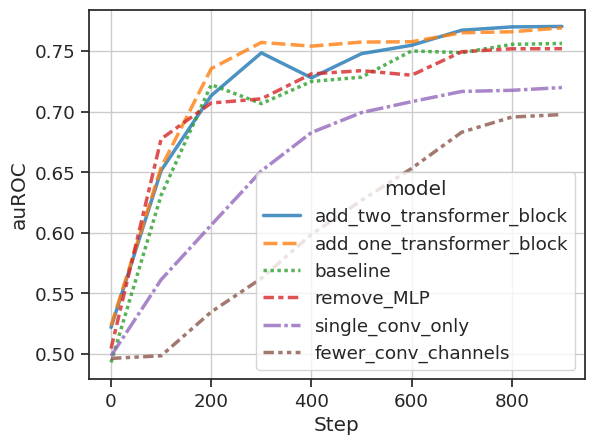

In [83]:
g = sns.lineplot(
  data=model_df[(model_df["metric"] == "auc")],
  x="round",
  y="mean",
  hue="model",
  style="model",
  alpha=0.8,
)
g.set_xlabel("Step")
g.set_ylabel("auROC");

And here are the max auROC values for each model (by step 1,000):

In [84]:
print(max_auc_by_model.sort_values(ascending=False))

model
add_two_transformer_block    0.770343
add_one_transformer_block    0.769196
baseline                     0.756317
remove_MLP                   0.752024
single_conv_only             0.719931
fewer_conv_channels          0.697637
Name: mean, dtype: float64


Some observations and hypotheses based on these results:

* **Convolutions are critical**: The `single_conv_only` model underperforms relative to the baseline, and reducing the number of convolutional filters degrades performance further. This
suggests that having multiple convolutional layers with sufficient capacity is important for learning meaningful sequence features. It may be worth exploring deeper convolutional stacks or wider kernels.

* **Transformer blocks help**: Adding one or two self-attention blocks gives a modest but consistent improvement in auROC, despite the input sequences being only 200 bp long. This
supports the idea that even short DNA windows can benefit from modeling long-range dependencies.

* **MLPs may be unnecessary**: Surprisingly, removing the MLP blocks doesn’t drastically hurt performance. This suggests that most of the representational power is coming from earlier
convolutional layers, and the additional MLP layers may be redundant.

* **Training dynamics**: Models with transformer blocks exhibit noisier validation loss during early training. This instability might be reduced with a smaller initial learning rate.

While we won’t exhaustively optimize hyperparameters here, these results demonstrate the value of modular model exploration and raise intriguing questions for further study.

### **Evaluating on the Test Split**

The final step is to evaluate our best-performing model on the held-out test set. This ensures that the model’s performance generalizes to completely unseen data and was not overfit to the training or validation distributions. We reload the checkpoint for the top model—selected based on the highest validation auROC—and evaluate it on the test split:

In [89]:
from dlfb.utils.restore import restore

# Identify best-performing model variant based on validation auROC.
top_model = model_order[0]

# Restore the trained model state from disk.
state, _ = restore(
  assets(f"dna/models/{top_model}"),
  models[top_model].create_train_state(
    rng=rng_init,
    dummy_input=next(dataset_splits["train"].as_numpy_iterator())["sequences"],
    tx=optax.adamw(
      optax.cosine_decay_schedule(
        init_value=learning_rate,
        decay_steps=num_steps,
      )
    ),
  ),
)

# Evaluate on the held-out test set.
test_batch = next(dataset_splits["test"].as_numpy_iterator())
metrics = eval_step(state, test_batch)
print(metrics)

{'loss': 0.5123619437217712, 'accuracy': 0.75, 'auc': 0.8196078431372549}


Success! Our best model achieves a comparable AUC on the test set to what we saw on the validation set, demonstrating good generalization to unseen data.

### **Extensions and Improvements**

There are many ways to extend this work—in terms of both analyzing model behavior and exploring new modeling directions.

A few analysis ideas:

* **Failure (error) analysis**: Inspect misclassified sequences. Do they correspond to originally noisy or lower magnitude ChIP-seq peaks? Are there weak motif matches within them? Trace these sequences back to the raw data to understand the source of prediction errors.

* **Motif discovery**: Use saliency maps to extract high-signal regions and align them to known motifs from databases like JASPAR or HOCOMOCO. You can also explore tools like TF-MoDISco for automatic motif discovery based on contribution scores.

* **Attribution comparisons**: Compare in silico mutagenesis and input gradients across TFs. Do easier tasks yield more consistent or interpretable saliency patterns?

* **Cross-TF generalization**: Evaluate a model trained on one TF against the validation data for another. Which TFs generalize well to others? This could reveal shared motif features or similarities in binding logic.

* **Saliency reproducibility**: Compare saliency maps across different training runs or architectures to assess how reliably motif patterns are captured.

And some potential modeling extensions:

* **Model optimization:** Tune architectural hyperparameters such as the number of convolutional filters, kernel width, dropout rate, or transformer head count and MLP size.

* **Positional encodings**: Add sinusoidal or learned positional embeddings to improve transformer modeling of sequence order—especially valuable for longer DNA sequences.

* **Multitask setup**: Build a multitask model that predicts binding for all TFs simultaneously. This allows shared representations across tasks and may improve performance on
lower-data TFs with less data.

* **Quantitative binding prediction:** Instead of binary classification, predict continuous binding intensity (e.g., ChIPseq signal). This would require adapting the model for sequence-to-sequence or dense regression output.

* **Pretraining**: Fine-tune pretrained DNA models such as DNABERT or Nucleotide Transformer to leverage prior genomic knowledge and improve performance with less data.

* **Data augmentation:** Improve generalization with reverse complements, shifted windows (jittering), or synthetic motif insertions.

These directions offer exciting possibilities for improving accuracy, interpretability, and generalizability in TF binding prediction.

---

## **Summary**

In this chapter, we explored the fascinating world of gene regulation through transcription factor binding. Starting with simple convolutional models, we built a foundation for understanding how neural networks can learn to recognize sequence motifs in raw DNA sequences. From there, we incrementally increased model complexity—adding batch normalization, dropout, and even transformer blocks, to investigate how architectural changes impact performance. 

This gradual, modular approach to model development not only helped clarify the strengths of each component, but also made debugging and evaluation more manageable. Along the way, we touched on model interpretability, performance benchmarking, and ideas for deeper analysis and extensions.